## **Economic Volatility and Housing Returns: Is There a Real Estate Risk Premium Across U.S. States?**
# Project One
## Introduction
**Research Question:** Does state-level labor market volatility predict higher housing returns through a risk premium mechanism?

This project studies whether local economic risk is reflected in U.S. housing market outcomes. I will explore whether state-level labor market volatility (X), measured using the variability of unemployment rates, is related to state-level housing returns (Y), measured using the FHFA House Price Index. The mechanism (Z) is a risk-premium channel; if local economic conditions are more uncertain, housing cash flows and resale values may be riskier, and therefore, investors and households may require higher expected returns. To explore these ideas, I use the USA Real Estate Dataset from Kaggle, which contains property-level listings and characteristics that I aggregate to the state level to summarize housing market conditions, and combine it with FHFA state-level quarterly house price indexes and monthly state unemployment data. I also plan to use state-level median income and population data from FRED as controls. 

Ling and Naranjo (1997) show that commercial real estate returns take macroeconomic risk factors into consideration, supporting the idea that real estate may earn compensation for systematic risk. Shilling (2003) argues that real estate risk premia are difficult to measure and may appear very large when using survey-based expectations, which highlights the importance of measuring returns and risk for investors. More recent work emphasizes heterogeneity across assets and locations, where Sagi (2020) shows that real estate returns vary with holding periods and illiquidity/search frictions, while Zhu and Lizieri (2022) find that location-specific risk is priced in REIT returns through a “local beta” channel. Finally, Anundsen and Heeboll (2015) emphasize that credit conditions can amplify housing cycles, which suggests that local risk can also show through financial mechanisms.

Earlier work by Case and Shiller (1988) shows that housing markets exhibit substantial variation in returns across regions, which indicates that local conditions play an important role in determining price dynamics. Research on housing supply and regional growth highlights that housing prices respond to local economic and geographic constraints; Glaeser, Gyourko, and Saiz (2008) and Saiz (2010) show that limited housing supply and geographic barriers can amplify price increases in certain markets. Other studies link housing markets to broader macroeconomic risk and credit conditions: Piazzesi, Schneider, and Tuzel (2007) demonstrate that housing markets interact closely with consumption and asset pricing dynamics, while Mian and Sufi (2009) show that local credit expansion and economic shocks can strongly influence housing outcomes across regions.

The summary statistics, maps, and regression results show clear cross-state variation in both housing prices and labor market volatility, suggesting that states with more volatile economic conditions experience systematically different housing market outcomes. While the simple relationship between unemployment volatility and housing price growth is weak in scatterplots, the regression analysis strengthens the hypothesis: across multiple specifications, unemployment volatility is positively associated with long-run housing price growth even after controlling for income, population, housing market characteristics, and domestic migration flows derived from U-Haul transaction data. The interaction results indicate that the effect is weaker in high-income states, and adding migration controls does not change the core finding, confirming that the relationship reflects labor market risk rather than demand-side population dynamics. The regression tree and random forest analyses show that housing market structure, measured by price per square foot, is the dominant predictor of long-run appreciation, followed by migration flows, with unemployment volatility playing a smaller but present role. This suggests the risk premium is more conditional than universal, as it shows up most clearly in affordable, lower-migration states where labor market instability has not already been priced into the market. Together, the results provide evidence that economic risk is partially reflected in housing returns, but that structural housing market characteristics and population dynamics are especially important in shaping cross-state differences in housing appreciation.

## Chosen Variables

Two outcome variables are used to measure how economic risk may be priced into housing markets. First, I construct each state’s median listing price per square foot. Second, I measure housing appreciation using state-level HPI growth over time from the FHFA House Price Index (HPI), which acts as a proxy for housing returns. My main explanatory variable is local economic volatility, which is measured as the standard deviation of the state unemployment rate from the BLS Local Area Unemployment Statistics (LAUS) dataset from 2010 to 2023. This variable captures how unstable local labor market conditions are for each state. The Z mechanism is risk compensation, if housing is an asset, then states with more volatile economic conditions may require higher expected returns to attract buyers and investors, which could show up either in higher long-run appreciation (FHFA) or in higher current price levels if risk is capitalized into housing values.

To address omitted variable bias and to account for differences in state size or income, I include control variables from FRED, such as state population and median household income, which proxy for market size and local purchasing power. I also construct state-level measures of housing composition from the Kaggle dataset; these variables will account for differences in housing prices due to bigger homes or land lots.


### Variables - List


**Outcomes (Y)**

1. Kaggle Median listing price per square foot (state-level)
2. FHFA HPI growth (state-level)

**Explanatory Variables (X)**

From LAUS (economic risk)
1. Unemployment volatility (std dev of unemployment rate, 2010–2023)
2. Average unemployment rate (mean, 2010–2023)
3. Unemployment trend (2023 rate − 2010 rate)

From FRED (controls)

4. Median household income (state-year)
5. Population (state-year)

From Kaggle

6. Median house size (sqft) by state
7. Median lot size (acre_lot) by state
8. Share of listings that are “ready_to_build” by state

### Datasets
* **USA Real Estate Dataset (Kaggle/Main Dataset)**

  * **Source:** Kaggle
  * **Temporal coverage:** Snapshot of listings (2022-2023)
  * **Geographical coverage:** Property-level listings across the U.S.
  * **Variables:** Listing price, beds, baths, house size, lot size, listing status, and location identifiers

* **FHFA House Price Index (HPI)**

  * **Source:** FHFA
  * **Temporal coverage:** Quarterly
  * **Geographical coverage:** U.S. state level
  * **Variables:** HPI index value by state-quarter

* **BLS Local Area Unemployment Statistics (LAUS)**

  * **Source:** U.S. BLS
  * **Temporal coverage:** Monthly
  * **Geographical coverage:** U.S. state level
  * **Variables:** Unemployment rate by state-month

* **FRED State-Level Controls**

  * **Source:** FRED
  * **Temporal coverage:** Annual
  * **Geographical coverage:** U.S. state level
  * **Variables:** Median household income and population by state-year


## Data Cleaning/Loading

In [10]:
#SETUP
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

DATA = Path("data")
OUT  = Path("output")
OUT.mkdir(exist_ok=True)
pd.set_option("display.max_columns", 100)
pd.set_option("display.width", 120)

In [11]:
#KAGGLE DATASET
re = pd.read_csv(DATA / "/Users/ziadsaad/Desktop/225 new project/eco225-project-zeyadsaad1/data/usa_real_estate.csv")

# Standardize column names
re.columns = [c.strip().lower() for c in re.columns]

# Keep only columns needed
keep_cols = ["status", "price", "bed", "bath", "acre_lot", "street", "city", "state", "zip_code", "house_size"]
re = re[[c for c in keep_cols if c in re.columns]].copy()

# Drop unwanted areas
drop_states = {"Puerto Rico", "Virgin Islands", "District of Columbia"}
re["state"] = re["state"].astype(str).str.strip()
re = re[~re["state"].isin(drop_states)].copy()

# Basic cleaning: drop missing key fields
re = re.dropna(subset=["state", "price", "house_size"])

# Convert numeric columns
for c in ["price", "bed", "bath", "acre_lot", "zip_code", "house_size"]:
    if c in re.columns:
        re[c] = pd.to_numeric(re[c], errors="coerce")

# Remove impossible/invalid values
re = re[(re["price"] > 0) & (re["house_size"] > 0)]
re = re[re["house_size"] <= 20000]  # remove extreme outliers in sqft (safe cap)
re = re[re["price"] <= 10_000_000]  # remove extreme outliers (safe cap)

# Create price per square foot
re["price_per_sqft"] = re["price"] / re["house_size"]
re = re[(re["price_per_sqft"] > 1) & (re["price_per_sqft"] < 5000)]  # trim extreme PPSF

# Clean state strings
re["state"] = re["state"].astype(str).str.strip()


In [12]:
#UNEMPLOYMENT
unemp = pd.read_csv(DATA / "/Users/ziadsaad/Desktop/225 new project/eco225-project-zeyadsaad1/data/unemployment_state.csv")
unemp.columns = [c.strip() for c in unemp.columns]

# Rename columns
unemp = unemp.rename(columns={
    "State": "state",
    "Year": "year",
    "Month": "month",
    "Percent (%) of Labor Force Unemployed in State/Area": "unemp_rate"
})

# Keep only needed columns
unemp = unemp[["state", "year", "month", "unemp_rate"]].copy()

# Drop unwanted non-state entries
drop_places = {"Los Angeles County", "District of Columbia", "New York city"}
unemp["state"] = unemp["state"].astype(str).str.strip()
unemp = unemp[~unemp["state"].isin(drop_places)].copy()

# Convert type
unemp["year"] = pd.to_numeric(unemp["year"], errors="coerce")
unemp["month"] = pd.to_numeric(unemp["month"], errors="coerce")

unemp["unemp_rate"] = (
    unemp["unemp_rate"]
    .astype(str)
    .str.replace("%", "", regex=False)
    .str.strip()
)
unemp["unemp_rate"] = pd.to_numeric(unemp["unemp_rate"], errors="coerce")

# Drop missing & invalid
unemp = unemp.dropna(subset=["state", "year", "month", "unemp_rate"])
unemp = unemp[(unemp["month"] >= 1) & (unemp["month"] <= 12)]
unemp = unemp[(unemp["year"] >= 2010) & (unemp["year"] <= 2023)].copy()

# Create a monthly date (end-of-month) for time series
unemp["date"] = pd.to_datetime(
    unemp["year"].astype(int).astype(str) + "-" + unemp["month"].astype(int).astype(str) + "-01",
    errors="coerce"
)

# Quarter and year-quarter label (for merging to FHFA)
unemp["quarter"] = ((unemp["month"] - 1) // 3 + 1).astype(int)
unemp["year_quarter"] = unemp["year"].astype(int).astype(str) + "Q" + unemp["quarter"].astype(int).astype(str)

# Quarterly unemployment rate (mean within quarter)
unemp_q = (
    unemp.groupby(["state", "year", "quarter"], as_index=False)
    .agg(unemp_rate_q=("unemp_rate", "mean"))
)

# Quarterly unemployment volatility (within quarter: std across months)
unemp_q_vol = (
    unemp.groupby(["state", "year", "quarter"], as_index=False)
    .agg(unemp_vol_q=("unemp_rate", "std"))
)

# Merge quarterly level + within-quarter volatility
unemp_q = unemp_q.merge(unemp_q_vol, on=["state", "year", "quarter"], how="left")

# State-level volatility over full sample (Project 1 main X)
unemp_state = (
    unemp.groupby("state", as_index=False)
    .agg(
        unemp_volatility=("unemp_rate", "std"),
        unemp_mean=("unemp_rate", "mean"),
        unemp_min=("unemp_rate", "min"),
        unemp_max=("unemp_rate", "max")
    )
)

In [13]:
#FHFA HPI
hpi = pd.read_csv(DATA / "/Users/ziadsaad/Desktop/225 new project/eco225-project-zeyadsaad1/data/FHFA_HPI.csv")

# Assign column names
hpi.columns = ["state_abbr", "year", "quarter", "hpi"]

# Drop DC
hpi["state_abbr"] = hpi["state_abbr"].astype(str).str.strip()
hpi = hpi[hpi["state_abbr"] != "DC"].copy()

# Convert types
hpi["year"] = pd.to_numeric(hpi["year"], errors="coerce")
hpi["quarter"] = pd.to_numeric(hpi["quarter"], errors="coerce")
hpi["hpi"] = pd.to_numeric(hpi["hpi"], errors="coerce")

# Drop missing
hpi = hpi.dropna(subset=["state_abbr", "year", "quarter", "hpi"])

# Keep 2010–2023
hpi = hpi[(hpi["year"] >= 2010) & (hpi["year"] <= 2023)].copy()

# Ensure quarter is valid
hpi = hpi[hpi["quarter"].isin([1, 2, 3, 4])].copy()

# Create a quarterly date for time-series work later
# (Using first month of each quarter)
quarter_month_map = {1: 1, 2: 4, 3: 7, 4: 10}
hpi["month"] = hpi["quarter"].map(quarter_month_map)

hpi["date"] = pd.to_datetime(
    hpi["year"].astype(int).astype(str) + "-" + hpi["month"].astype(int).astype(str) + "-01",
    errors="coerce"
)

# Sort
hpi = hpi.sort_values(["state_abbr", "year", "quarter"]).reset_index(drop=True)

# Create growth variables (returns proxies) 
# Quarterly log growth
hpi["hpi_log"] = np.log(hpi["hpi"])
hpi["hpi_log_growth_qoq"] = hpi.groupby("state_abbr")["hpi_log"].diff(1)

# Year-over-year log growth (4 quarters)
hpi["hpi_log_growth_yoy"] = hpi.groupby("state_abbr")["hpi_log"].diff(4)

# State-level appreciation
# Growth from first observation in 2010 to last observation in 2023
hpi_state = (
    hpi.groupby("state_abbr", as_index=False)
    .agg(
        hpi_2010=("hpi", "first"),
        hpi_2023=("hpi", "last")
    )
)

hpi_state["hpi_growth_2010_2023"] = np.log(hpi_state["hpi_2023"]) - np.log(hpi_state["hpi_2010"])


In [14]:
#FRED INCOME
income_raw = pd.read_csv(DATA / "/Users/ziadsaad/Desktop/225 new project/eco225-project-zeyadsaad1/data/median_hshd_income.csv")
income_raw.columns = [c.strip() for c in income_raw.columns]

income_raw["observation_date"] = pd.to_datetime(income_raw["observation_date"], errors="coerce")
income_raw["year"] = income_raw["observation_date"].dt.year

# Keep only 2010–2023
income_raw = income_raw[(income_raw["year"] >= 2010) & (income_raw["year"] <= 2023)].copy()

# State series columns (except date/year)
state_cols = [c for c in income_raw.columns if c not in ["observation_date", "year"]]

# Wide to long
income_long = income_raw.melt(
    id_vars=["year"],
    value_vars=state_cols,
    var_name="series_id",
    value_name="median_income"
)

# Extract state abbreviation by string position 
income_long["state_abbr"] = income_long["series_id"].str[8:10]

# Convert values to numeric
income_long["median_income"] = pd.to_numeric(income_long["median_income"], errors="coerce")

# clean panel
income = income_long[["state_abbr", "year", "median_income"]].dropna().copy()

# Drop DC
income = income[income["state_abbr"] != "DC"].copy()

income = income.sort_values(["state_abbr", "year"]).reset_index(drop=True)

In [15]:
#FRED POPULATION
pop_raw = pd.read_csv(DATA / "/Users/ziadsaad/Desktop/225 new project/eco225-project-zeyadsaad1/data/population.csv")
pop_raw.columns = [c.strip() for c in pop_raw.columns]

pop_raw["observation_date"] = pd.to_datetime(pop_raw["observation_date"], errors="coerce")
pop_raw["year"] = pop_raw["observation_date"].dt.year

# Keep only 2010–2023
pop_raw = pop_raw[(pop_raw["year"] >= 2010) & (pop_raw["year"] <= 2023)].copy()

state_cols = [c for c in pop_raw.columns if c not in ["observation_date", "year"]]

pop_long = pop_raw.melt(
    id_vars=["year"],
    value_vars=state_cols,
    var_name="series_id",
    value_name="population"
)

# Extract state abbreviation from "AKPOP" -> "AK"
pop_long["state_abbr"] = pop_long["series_id"].str[:2]

# Numeric conversion
pop_long["population"] = pd.to_numeric(pop_long["population"], errors="coerce")

# OPTIONAL but recommended: convert from thousands to people
pop_long["population"] = pop_long["population"] * 1000

population = pop_long[["state_abbr", "year", "population"]].dropna().copy()

# Drop DC if it appears (usually "DCPOP" could exist)
population = population[population["state_abbr"] != "DC"].copy()

population = population.sort_values(["state_abbr", "year"]).reset_index(drop=True)

In [16]:
# MERGING
state_to_abbr = {
    "Alabama":"AL","Alaska":"AK","Arizona":"AZ","Arkansas":"AR","California":"CA","Colorado":"CO",
    "Connecticut":"CT","Delaware":"DE","Florida":"FL","Georgia":"GA","Hawaii":"HI","Idaho":"ID",
    "Illinois":"IL","Indiana":"IN","Iowa":"IA","Kansas":"KS","Kentucky":"KY","Louisiana":"LA",
    "Maine":"ME","Maryland":"MD","Massachusetts":"MA","Michigan":"MI","Minnesota":"MN","Mississippi":"MS",
    "Missouri":"MO","Montana":"MT","Nebraska":"NE","Nevada":"NV","New Hampshire":"NH","New Jersey":"NJ",
    "New Mexico":"NM","New York":"NY","North Carolina":"NC","North Dakota":"ND","Ohio":"OH","Oklahoma":"OK",
    "Oregon":"OR","Pennsylvania":"PA","Rhode Island":"RI","South Carolina":"SC","South Dakota":"SD",
    "Tennessee":"TN","Texas":"TX","Utah":"UT","Vermont":"VT","Virginia":"VA","Washington":"WA",
    "West Virginia":"WV","Wisconsin":"WI","Wyoming":"WY"
}
crosswalk = pd.DataFrame(list(state_to_abbr.items()), columns=["state", "state_abbr"])

# prevent duplicates
def attach_state_abbr(df, state_col="state"):
    df = df.copy()
    df[state_col] = df[state_col].astype(str).str.strip()
    if "state_abbr" in df.columns:
        df = df.drop(columns=["state_abbr"])
    return df.merge(crosswalk, left_on=state_col, right_on="state", how="left")

# 2) Kaggle
re = attach_state_abbr(re, state_col="state")

# Drop non-states / missing
re["state"] = re["state"].replace({"nan": None})
re = re[re["state"].notna()].copy()
re = re[re["state"] != "Guam"].copy()
re = re.dropna(subset=["state_abbr"]).copy()

# 3) Unemployment state summary
unemp_state = attach_state_abbr(unemp_state, state_col="state")

# missing
bad_kaggle = re.loc[re["state_abbr"].isna(), "state"].drop_duplicates().head(10)
bad_unemp = unemp_state.loc[unemp_state["state_abbr"].isna(), "state"].drop_duplicates().head(10)

In [17]:
# Kaggle state-level housing summary
kaggle_state = (
    re.groupby(["state", "state_abbr"], as_index=False)
      .agg(
          listings=("price", "size"),
          avg_price=("price", "mean"),
          med_price=("price", "median"),
          avg_ppsf=("price_per_sqft", "mean"),
          med_ppsf=("price_per_sqft", "median"),
          avg_house_size=("house_size", "mean"),
          med_house_size=("house_size", "median"),
      )
      .sort_values("state_abbr")
      .reset_index(drop=True)
)

# (share ready_to_build)
if "status" in re.columns:
    status_share = (
        re.assign(is_ready_to_build=(re["status"].astype(str).str.lower() == "ready_to_build").astype(int))
          .groupby(["state", "state_abbr"], as_index=False)
          .agg(share_ready_to_build=("is_ready_to_build", "mean"))
    )
    kaggle_state = kaggle_state.merge(status_share, on=["state", "state_abbr"], how="left")


In [18]:
# unemployment  state-level summary

unemp_state_small = unemp_state[["state_abbr", "unemp_volatility", "unemp_mean", "unemp_min", "unemp_max"]].copy()


In [19]:
# Income + Population state-level summaries

income_state = income.groupby("state_abbr", as_index=False).agg(
    median_income_mean=("median_income", "mean")
)

pop_state = population.groupby("state_abbr", as_index=False).agg(
    pop_mean=("population", "mean")
)

In [20]:
# FHFA state-level summary

fhfa_state = hpi_state[["state_abbr", "hpi_growth_2010_2023"]].copy()

fhfa_extra = (
    hpi.groupby("state_abbr", as_index=False)
       .agg(
           hpi_yoy_mean=("hpi_log_growth_yoy", "mean"),
           hpi_yoy_vol=("hpi_log_growth_yoy", "std"),
       )
)

fhfa_state = fhfa_state.merge(fhfa_extra, on="state_abbr", how="left")


In [21]:
# Final merge

final_state = (
    kaggle_state
    .merge(unemp_state_small, on="state_abbr", how="inner")
    .merge(fhfa_state, on="state_abbr", how="inner")
    .merge(income_state, on="state_abbr", how="inner")
    .merge(pop_state, on="state_abbr", how="inner")
)

final_state.to_csv(OUT / "final_state_dataset.csv", index=False)

## Summary Statistics Tables

In [22]:
from IPython.display import display, HTML

# Y and X variables
Y = "hpi_growth_2010_2023"
X_vars = [
    "unemp_volatility",
    "unemp_mean",
    "median_income_mean",
    "pop_mean",
    "hpi_yoy_vol",
    "avg_price",
    "avg_ppsf",
    "avg_house_size",
    "share_ready_to_build",
    "listings"
]

vars_to_summarize = [Y] + X_vars

df_sum = final_state[vars_to_summarize].copy()

# Build summary stats table
summary = pd.DataFrame({
    "N": df_sum.count(),
    "Mean": df_sum.mean(numeric_only=True),
    "Std. Dev.": df_sum.std(numeric_only=True),
    "Min": df_sum.min(numeric_only=True),
    "Max": df_sum.max(numeric_only=True),
})

var_labels = {
    "hpi_growth_2010_2023": "HPI growth 2010–2023 (log change)",
    "unemp_volatility": "Unemployment volatility (std. dev., % points)",
    "unemp_mean": "Average unemployment rate (%)",
    "median_income_mean": "Median household income (USD)",
    "pop_mean": "Population (people)",
    "hpi_yoy_vol": "HPI volatility (std. dev., log growth)",
    "avg_price": "Average listing price (USD)",
    "avg_ppsf": "Average price per sq ft (USD)",
    "avg_house_size": "Average house size (sq ft)",
    "share_ready_to_build": "Share ready-to-build listings (%)",
    "listings": "Number of listings"
}

summary = summary.round(3)
summary.index.name = "Variable"
summary = summary.reset_index()

summary["Variable"] = summary["Variable"].map(var_labels)

display(HTML("<h3>Table 1: Summary Statistics</h3>"))
display(HTML(summary.to_html(index=False, border=0)))

Variable,N,Mean,Std. Dev.,Min,Max
HPI growth 2010–2023 (log change),50,0.649,0.157,0.392,0.976
"Unemployment volatility (std. dev., % points)",50,2.096,0.649,0.865,3.991
Average unemployment rate (%),50,5.450,1.093,2.904,8.071
Median household income (USD),50,61894.857,9509.040,42227.143,83142.143
Population (people),50,6454974.087,7236563.086,579258.214,38786632.571
"HPI volatility (std. dev., log growth)",50,0.051,0.013,0.029,0.090
Average listing price (USD),50,493795.324,201791.315,246073.657,1156447.511
Average price per sq ft (USD),50,240.362,116.664,123.902,779.211
Average house size (sq ft),50,2083.317,199.011,1509.695,2714.606
Share ready-to-build listings (%),50,0.012,0.014,0.000,0.056


The summary statistics show substantial cross-state variation in both the outcome and the explanatory variables. FHFA house price growth from 2010–2023 differs across states, confirming that long-run appreciation was not uniform. Unemployment volatility also varies across states, showing how some states face  greater macroeconomic risk than others. Unemployment volatility and average unemployment are not the same thing; this is important because our research question inquires about risk (instability), not just weak economic conditions.

The control and housing market variables also show dispersion, where population and median income differ widely. The Kaggle housing measures suggest that states have very different market structures and supply conditions. These distributions are consistent with our economic story that states differ in economic risk, fundamentals, and housing market tightness.

In [23]:
df = final_state.copy()

# Create high-volatility indicator above median
median_vol = df["unemp_volatility"].median()
df["high_unemp_vol"] = (df["unemp_volatility"] > median_vol).astype(int)

# Variables to summarize by subgroup
subgroup_vars = [
    "hpi_growth_2010_2023",
    "unemp_volatility",
    "unemp_mean",
    "median_income_mean",
    "pop_mean",
    "avg_price",
    "avg_ppsf",
    "avg_house_size",
    "share_ready_to_build",
    "listings"
]

table2_means = (
    df.groupby("high_unemp_vol")[subgroup_vars]
      .mean()
      .round(3)
)

table2_means.index = ["Low Unemp Volatility", "High Unemp Volatility"]
table2_means

,hpi_growth_2010_2023,unemp_volatility,unemp_mean,median_income_mean,pop_mean,avg_price,avg_ppsf,avg_house_size,share_ready_to_build,listings
Low Unemp Volatility,0.599,1.579,4.799,62332.400,4520700.954,434133.706,200.218,2140.314,0.008,23325.48
High Unemp Volatility,0.700,2.614,6.100,61457.314,8389247.220,553456.941,280.505,2026.319,0.015,42403.04


This table checks whether states with more unstable labor markets tend to have higher or lower long-run house price growth. If the risk-premium story is true, we would expect higher-volatility states to show higher appreciation as compensation for risk.

## Plots, Histograms, Figures

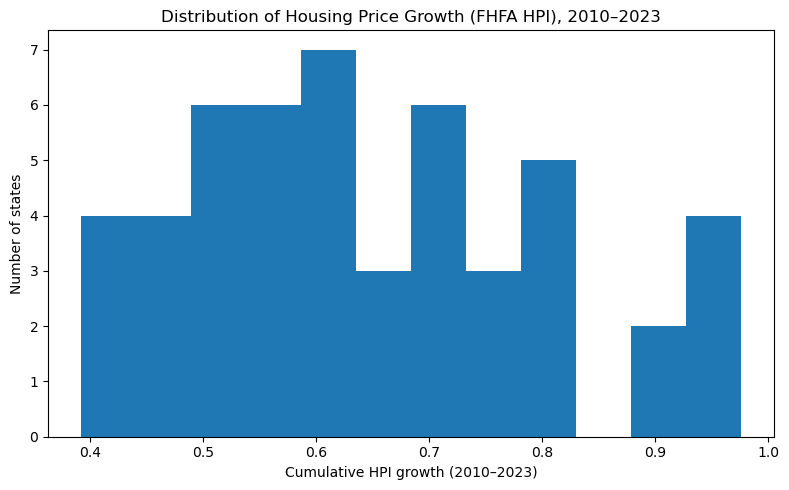

In [24]:
df = final_state.copy()

def _clean_for_plots(df):
 
    return df

df = _clean_for_plots(df)

# Plot 1: Histogram of Y (HPI growth 2010–2023)

plt.figure(figsize=(8,5))
plt.hist(df["hpi_growth_2010_2023"].dropna(), bins=12)
plt.title("Distribution of Housing Price Growth (FHFA HPI), 2010–2023")
plt.xlabel("Cumulative HPI growth (2010–2023)")
plt.ylabel("Number of states")
plt.tight_layout()
plt.show()

Cumulative FHFA house price growth is the project’s main outcome variable and directly measures long-run housing appreciation at the state level. How much do housing returns differ across U.S. states over the same time period? The distribution shows substantial variation in long-run housing growth across states. We can see that most states cluster in the middle (around 0.55–0.75 cumulative growth), but there is a notable right tail of states with very high appreciation (near 0.9–1.0). This suggests that housing market performance is not uniform across the U.S.

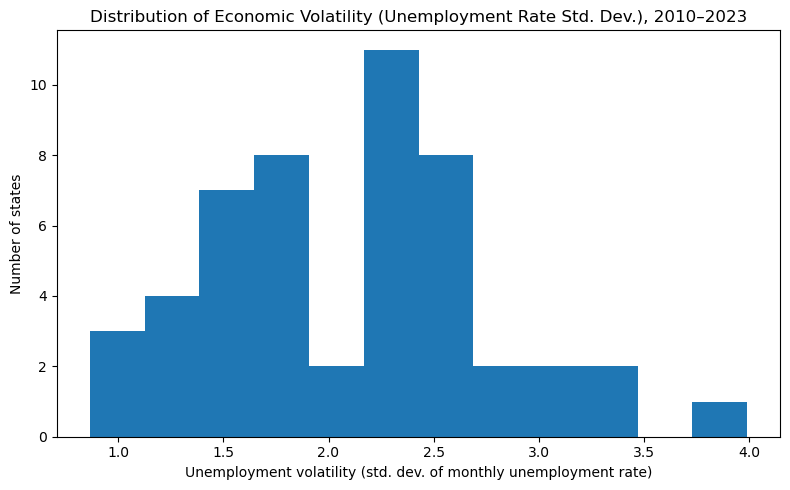

In [25]:
# Plot 2: Histogram of main X (unemployment volatility)

plt.figure(figsize=(8,5))
plt.hist(df["unemp_volatility"].dropna(), bins=12)
plt.title("Distribution of Economic Volatility (Unemployment Rate Std. Dev.), 2010–2023")
plt.xlabel("Unemployment volatility (std. dev. of monthly unemployment rate)")
plt.ylabel("Number of states")
plt.tight_layout()
plt.show()

Unemployment volatility is the main explanatory variable and proxy for state-level economic risk. How different are U.S. states in terms of economic volatility? If states don’t vary much in unemployment volatility, then it would be hard for economic risk to explain cross-state differences in housing appreciation. The distribution shows meaningful dispersion in unemployment volatility across states. Most states cluster around moderate volatility (roughly 1.5–2.6), but there is a clear right tail with a few states experiencing much more unstable labor markets (above 3.0). This supports the idea that “economic risk” is not uniform across states.

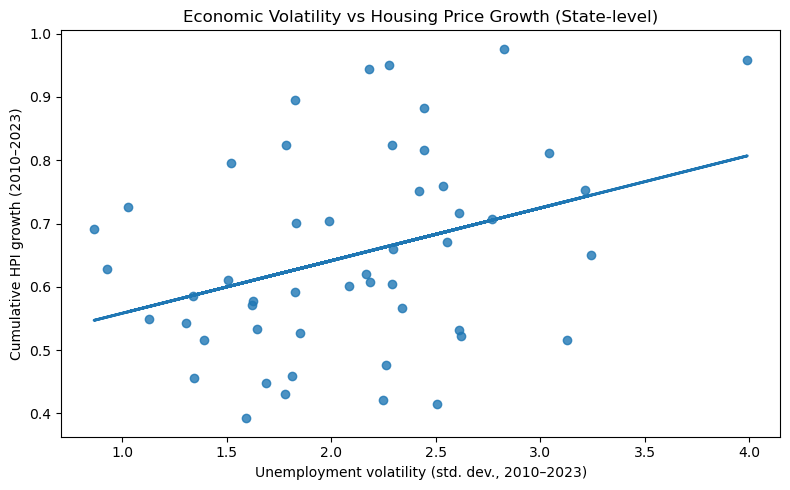

In [26]:
# Plot 3: Scatter with fitted line
plot3 = df.dropna(subset=["unemp_volatility", "hpi_growth_2010_2023"]).copy()

plt.figure(figsize=(8,5))

plt.scatter(
    plot3["unemp_volatility"],
    plot3["hpi_growth_2010_2023"],
    alpha=0.8
)

# fitted line
m, b = np.polyfit(plot3["unemp_volatility"], plot3["hpi_growth_2010_2023"], 1)
plt.plot(
    plot3["unemp_volatility"],
    m*plot3["unemp_volatility"] + b,
    linewidth=2
)

plt.title("Economic Volatility vs Housing Price Growth (State-level)")
plt.xlabel("Unemployment volatility (std. dev., 2010–2023)")
plt.ylabel("Cumulative HPI growth (2010–2023)")
plt.tight_layout()
plt.show()

This scatterplot compares the main explanatory variable to the main outcome. Do states with more volatile economic conditions tend to have higher long-run housing price growth? The points are widely scattered, and there is no strong upward trend. Some high-volatility states have high housing appreciation, others have average or low growth. Several low-volatility states still experienced strong price growth. This suggests that the relationship between economic risk and housing appreciation is not straightforward and that other factors, such as income, housing supply constraints, and market composition, may be important in explaining how risk relates to housing returns.

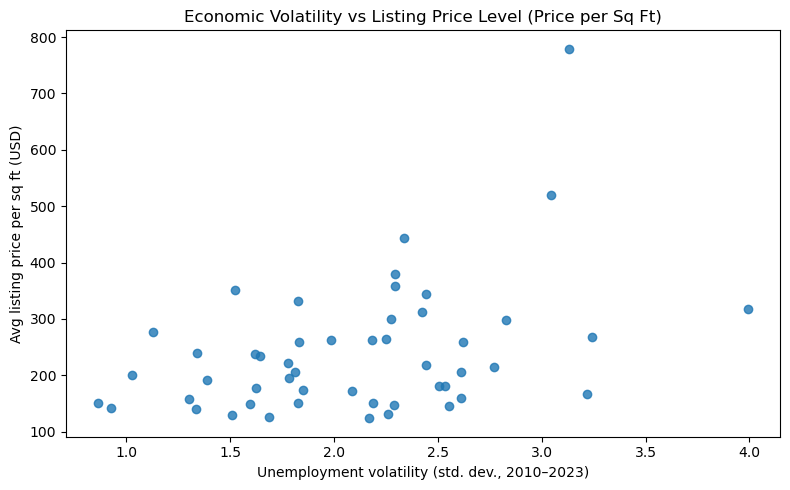

In [27]:
# Plot 4: Scatter of volatility vs price level proxy (mechanism / market structure check)

y_mech = "avg_ppsf" if "avg_ppsf" in df.columns else "avg_price"
plot4 = df.dropna(subset=["unemp_volatility", y_mech]).copy()

plt.figure(figsize=(8,5))
plt.scatter(plot4["unemp_volatility"], plot4[y_mech], alpha=0.8)
plt.title(f"Economic Volatility vs Listing Price Level ({'Price per Sq Ft' if y_mech=='avg_ppsf' else 'Average Price'})")
plt.xlabel("Unemployment volatility (std. dev., 2010–2023)")
plt.ylabel("Avg listing price per sq ft (USD)" if y_mech=="avg_ppsf" else "Average listing price (USD)")
plt.tight_layout()
plt.show()

This figure connects unemployment volatility to a different housing outcome, the current price level. This investigates whether volatility affects appreciation vs whether it is associated with current listing prices. The scatter shows no clear linear relationship. Most states cluster between roughly 300 per square foot across a range of volatility levels. The pattern suggests that housing price levels are likely driven more by factors like income, demand, and supply restrictions than solely by economic volatility, although volatility could still matter indirectly.

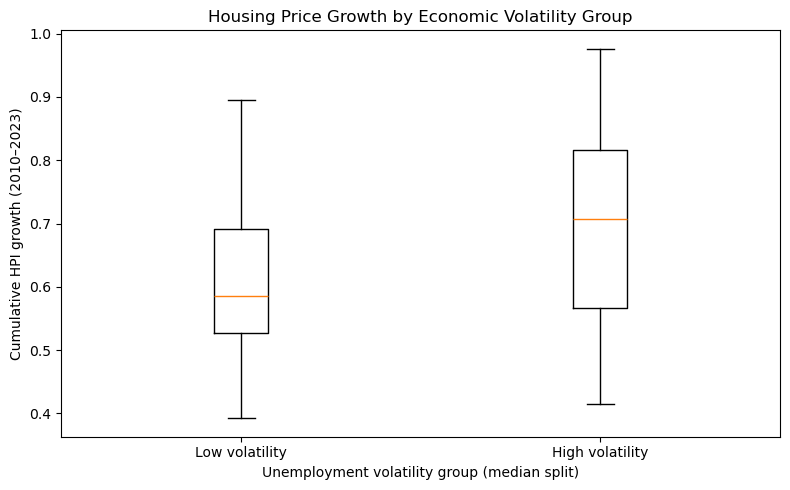

In [28]:
# Plot 5: Boxplot of Y by subgroup (High vs Low volatility)

tmp = df.dropna(subset=["unemp_volatility", "hpi_growth_2010_2023"]).copy()
median_vol = tmp["unemp_volatility"].median()
tmp["vol_group"] = np.where(tmp["unemp_volatility"] >= median_vol, "High volatility", "Low volatility")

low = tmp.loc[tmp["vol_group"]=="Low volatility", "hpi_growth_2010_2023"]
high = tmp.loc[tmp["vol_group"]=="High volatility", "hpi_growth_2010_2023"]

plt.figure(figsize=(8,5))
plt.boxplot([low, high], tick_labels=["Low volatility", "High volatility"])
plt.title("Housing Price Growth by Economic Volatility Group")
plt.xlabel("Unemployment volatility group (median split)")
plt.ylabel("Cumulative HPI growth (2010–2023)")
plt.tight_layout()
plt.show()

This plot compares the outcome variable across subgroups defined by economic volatility. Do high-volatility states experience systematically higher housing appreciation than low-volatility states? The high-volatility group has a noticeably higher median housing price growth than the low-volatility group. The high-volatility states also show a wider spread in outcomes, meaning housing growth is more dispersed when economic conditions are unstable.

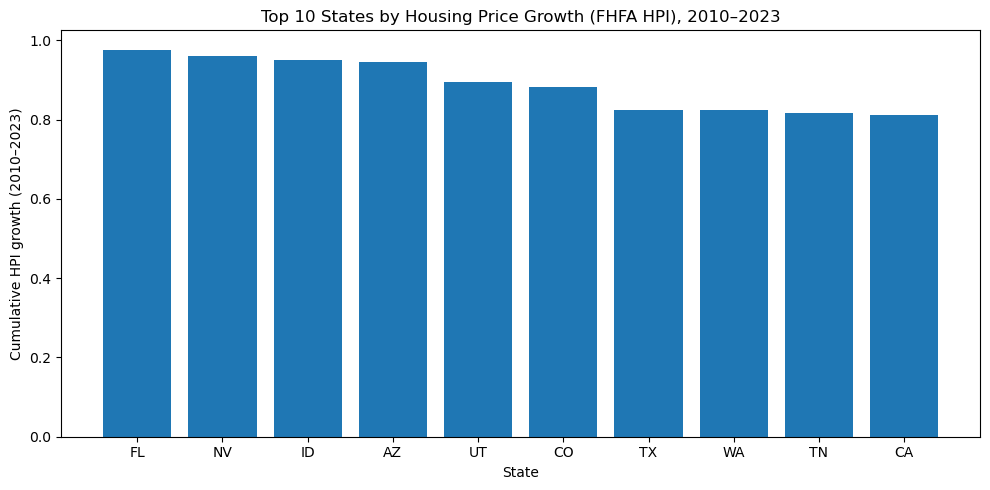

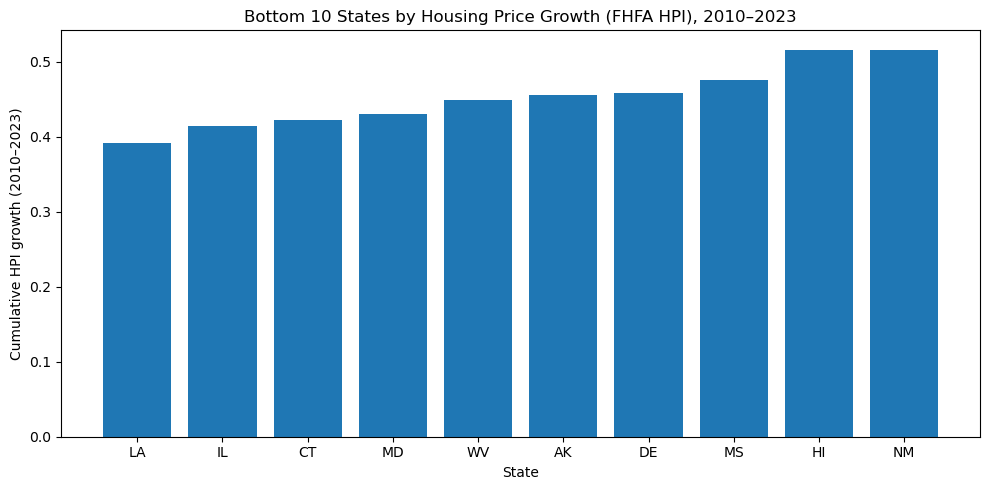

In [29]:
# Plot 6: Bar chart of top/bottom 10 states by HPI growth

rank = df.dropna(subset=["hpi_growth_2010_2023", "state_abbr"]).copy()
rank = rank.sort_values("hpi_growth_2010_2023", ascending=False)

top10 = rank.head(10)
bot10 = rank.tail(10).sort_values("hpi_growth_2010_2023", ascending=True)

plt.figure(figsize=(10,5))
plt.bar(top10["state_abbr"], top10["hpi_growth_2010_2023"])
plt.title("Top 10 States by Housing Price Growth (FHFA HPI), 2010–2023")
plt.xlabel("State")
plt.ylabel("Cumulative HPI growth (2010–2023)")
plt.tight_layout()
plt.show()

plt.figure(figsize=(10,5))
plt.bar(bot10["state_abbr"], bot10["hpi_growth_2010_2023"])
plt.title("Bottom 10 States by Housing Price Growth (FHFA HPI), 2010–2023")
plt.xlabel("State")
plt.ylabel("Cumulative HPI growth (2010–2023)")
plt.tight_layout()
plt.show()

These figures help identify which states experienced unusually high or unusually low housing appreciation, and how large the differences are. The figures show dispersion in long-run housing price growth across states. The top 10 states experienced close to a doubling in prices over the period, while the bottom 10 states had much weaker appreciation. 

# Project Two

## The Message
**Main Message:** States with more volatile labor markets tend to have higher long-run housing appreciation, but the relationship is not strictly linear.

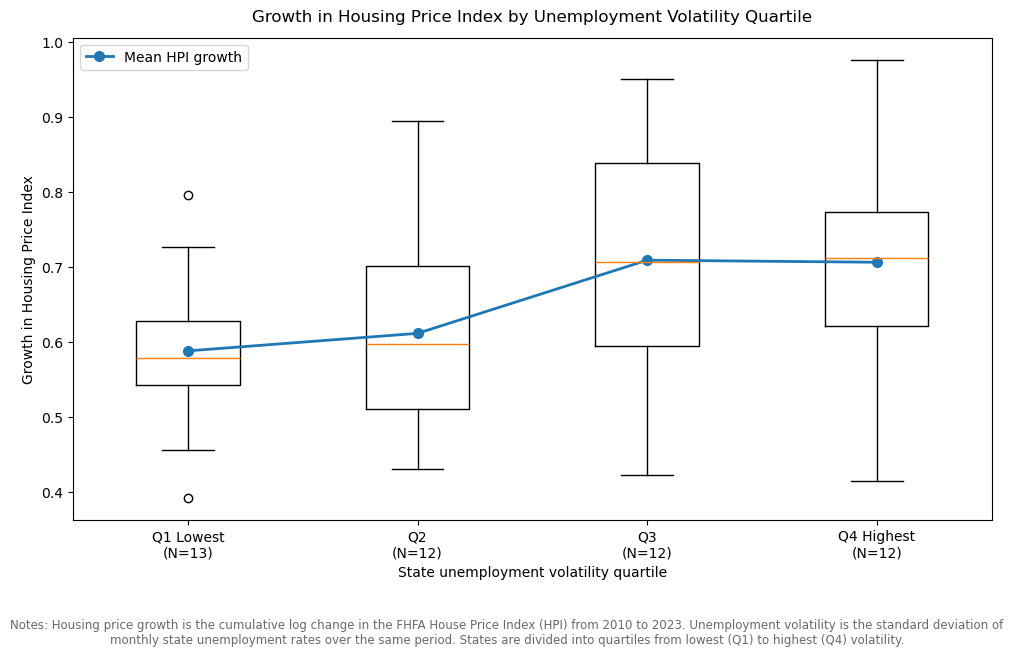

In [30]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

df = pd.read_csv("/Users/ziadsaad/Desktop/225 new project/eco225-project-zeyadsaad1/notebooks/output/final_state_with_migration_clean.csv")
df = df.dropna(subset=["unemp_volatility", "hpi_growth_2010_2023"])

df["vol_quartile"] = pd.qcut(df["unemp_volatility"], 4)

groups = [
    df[df["vol_quartile"] == q]["hpi_growth_2010_2023"]
    for q in sorted(df["vol_quartile"].unique())
]

counts = df["vol_quartile"].value_counts().sort_index()
labels = [
    "Q1 Lowest\n(N={})".format(counts.iloc[0]),
    "Q2\n(N={})".format(counts.iloc[1]),
    "Q3\n(N={})".format(counts.iloc[2]),
    "Q4 Highest\n(N={})".format(counts.iloc[3]),
]

fig, ax = plt.subplots(figsize=(10, 6))

ax.boxplot(groups, tick_labels=labels)

means = [g.mean() for g in groups]
ax.plot(
    [1, 2, 3, 4], means,
    marker="o", markersize=7, linewidth=2,
    label="Mean HPI growth"
)

ax.set_title("Growth in Housing Price Index by Unemployment Volatility Quartile", pad=12)
ax.set_xlabel("State unemployment volatility quartile")
ax.set_ylabel("Growth in Housing Price Index")
ax.legend(loc="upper left")

note = (
    "Notes: Housing price growth is the cumulative log change in the FHFA House Price Index (HPI) from 2010 to 2023. "
    "Unemployment volatility is the standard deviation of monthly state unemployment rates over the same period. "
    "States are divided into quartiles from lowest (Q1) to highest (Q4) volatility."
)
fig.text(0.5, -0.04, note, ha="center", va="top", fontsize=8.5, color="dimgray",
         wrap=True, transform=fig.transFigure)

plt.subplots_adjust(bottom=0.2)
plt.tight_layout()
plt.show()

This figure groups U.S. states into quartiles based on unemployment rate volatility. The y-axis reports the log change in FHFA House Price Index. The boxplots show the distribution of housing price growth within each volatility group. The visualization suggests a positive relationship between labor-market volatility and long-run housing appreciation. States in the lowest volatility quartile show the lowest average housing price growth, while states in the middle and upper volatility groups show higher mean appreciation. The spread of housing growth outcomes increases in the higher volatility groups, which is identified with wider interquartile ranges in Q3 and Q4. The relationship between the two variables is not strictly linear and is likely influenced by other factors such as income, population growth, and housing supply.

## Maps and Interpretations

**Map 1 - Housing Price Growth**

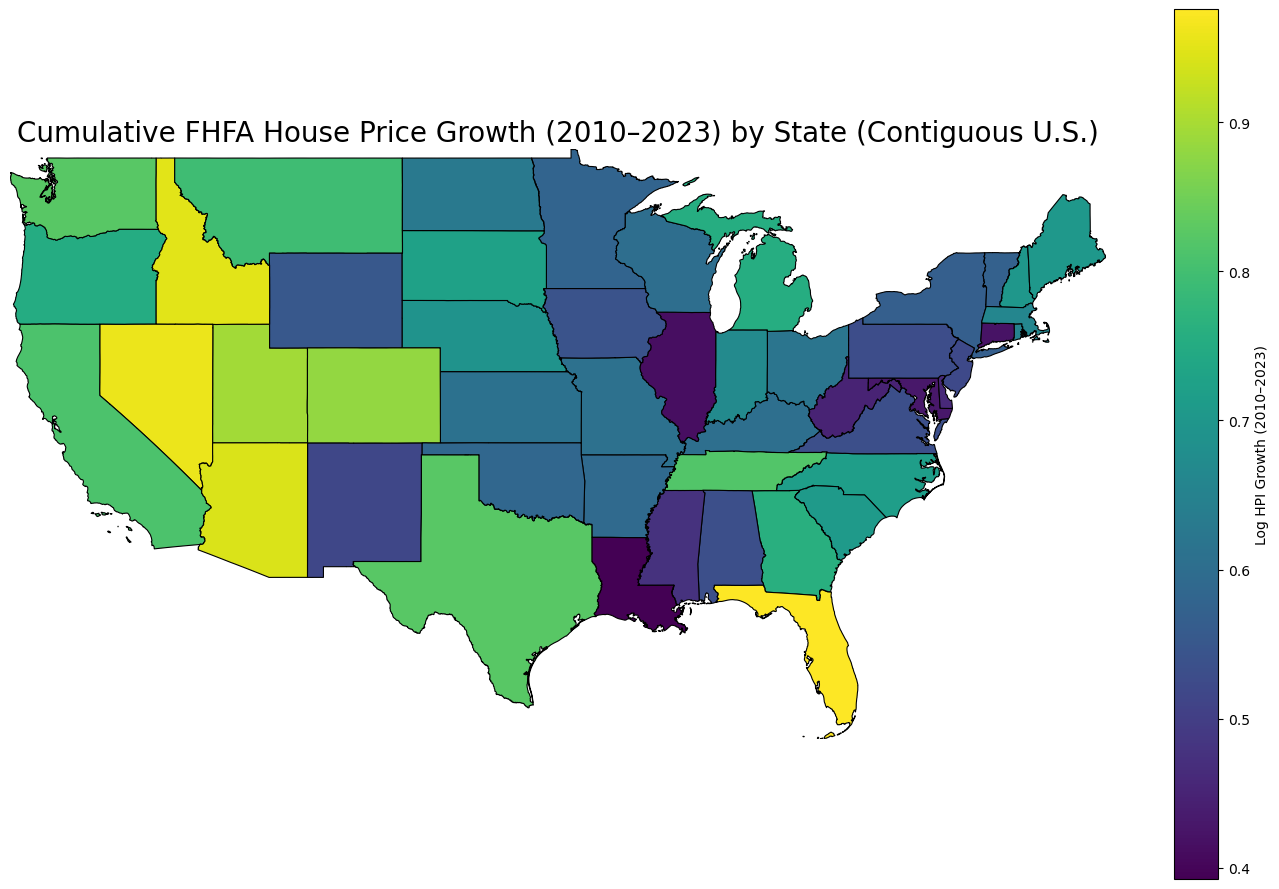

In [ ]:
import geopandas as gpd
import matplotlib.pyplot as plt

states = gpd.read_file("/Users/ziadsaad/Desktop/225 new project/eco225-project-zeyadsaad1/data/shapefiles/cb_2024_us_state_5m/cb_2024_us_state_5m.shp")
states = states[states["STUSPS"].isin(final_state["state_abbr"].unique())].copy()

drop = {"AK", "HI", "PR", "GU", "VI", "MP", "AS"}
states = states[~states["STUSPS"].isin(drop)].copy()

map_df = states.merge(final_state, left_on="STUSPS", right_on="state_abbr", how="left")

fig, ax = plt.subplots(1, 1, figsize=(14, 9))

map_df.plot(
    column="hpi_growth_2010_2023",
    cmap="viridis",
    linewidth=0.8,
    edgecolor="black",
    legend=True,
    legend_kwds={"label": "Log HPI Growth (2010–2023)"},
    ax=ax,
    missing_kwds={"color": "lightgrey", "edgecolor": "black", "hatch": "///", "label": "Missing"},
)

ax.set_title("Cumulative FHFA House Price Growth (2010–2023) by State (Contiguous U.S.)", fontsize=16)
ax.axis("off")

xmin, ymin, xmax, ymax = map_df.total_bounds
ax.set_xlim(xmin, xmax)
ax.set_ylim(ymin, ymax)

plt.tight_layout()
plt.show()


This map shows the spatial distribution of cumulative housing price appreciation across U.S. states, measured as the log change in the FHFA Housing Price Index between 2010 and 2023. This reveals strong regional variation in housing returns; states in the Mountain West, parts of the Southwest, and Florida experienced some of the highest appreciation over this period, while states in the Midwest and Appalachia showed lower appreciation. This geographic clustering suggests that regional economic conditions and migration patterns could play an important role in explaining housing returns.

**Map 2 - Unemployment Volatility**

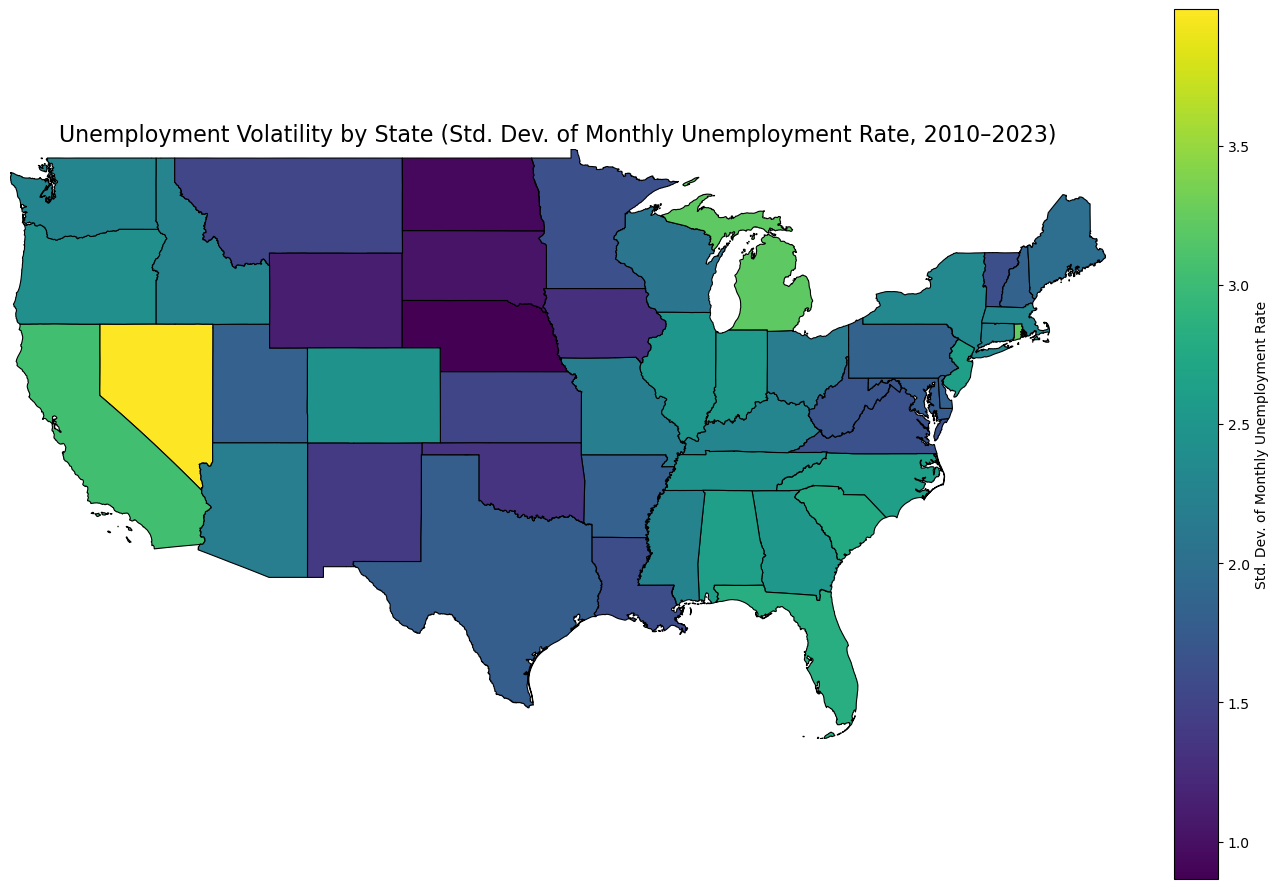

In [32]:
import geopandas as gpd
import matplotlib.pyplot as plt

states = gpd.read_file("/Users/ziadsaad/Desktop/225 new project/eco225-project-zeyadsaad1/data/shapefiles/cb_2024_us_state_5m/cb_2024_us_state_5m.shp")

states = states[states["STUSPS"].isin(final_state["state_abbr"].unique())].copy()

drop = {"AK", "HI", "PR", "GU", "VI", "MP", "AS"}
states = states[~states["STUSPS"].isin(drop)].copy()

map_df = states.merge(final_state, left_on="STUSPS", right_on="state_abbr", how="left")

fig, ax = plt.subplots(1, 1, figsize=(14, 9))

map_df.plot(
    column="unemp_volatility",
    cmap="viridis",
    linewidth=0.8,
    edgecolor="black",
    legend=True,
    legend_kwds={"label": "Std. Dev. of Monthly Unemployment Rate"},
    ax=ax,
    missing_kwds={"color": "lightgrey", "edgecolor": "black", "hatch": "///", "label": "Missing"},
)

ax.set_title("Unemployment Volatility by State (Std. Dev. of Monthly Unemployment Rate, 2010–2023)", fontsize=16)
ax.axis("off")

xmin, ymin, xmax, ymax = map_df.total_bounds
ax.set_xlim(xmin, xmax)
ax.set_ylim(ymin, ymax)

plt.tight_layout()
plt.show()

The second map shows the geographic distribution of economic risk using the standard deviation of the monthly unemployment rate between 2010 and 2023. The findings indicate that labor market volatility differs noticeably across states, with higher volatility in states with more cyclical economies such as Nevada, California, and Florida. States in the Great Plains and the Midwest show relatively low unemployment volatility, which demonstrates how economic risk is not equally distributed across the U.S.

**Map 3 - Risk-adjusted Housing Returns**

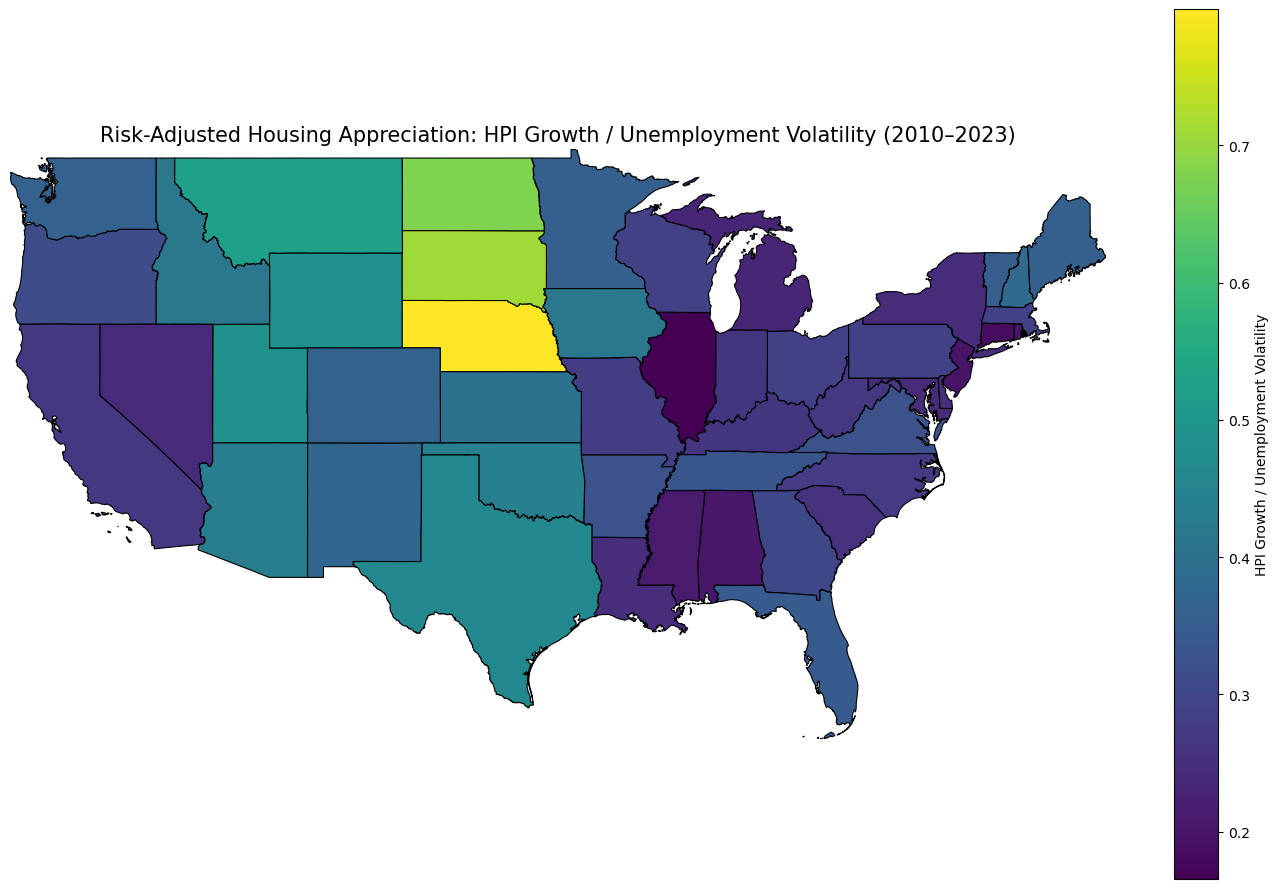

In [33]:
import geopandas as gpd
import matplotlib.pyplot as plt
import numpy as np

states = gpd.read_file("/Users/ziadsaad/Desktop/225 new project/eco225-project-zeyadsaad1/data/shapefiles/cb_2024_us_state_5m/cb_2024_us_state_5m.shp")
states = states[states["STUSPS"].isin(final_state["state_abbr"].unique())].copy()

drop = {"AK", "HI", "PR", "GU", "VI", "MP", "AS"}
states = states[~states["STUSPS"].isin(drop)].copy()

df1 = final_state.copy()
df1["risk_adjusted_growth"] = df1["hpi_growth_2010_2023"] / df1["unemp_volatility"].replace(0, np.nan)

map_df1 = states.merge(df1, left_on="STUSPS", right_on="state_abbr", how="left")

fig, ax = plt.subplots(1, 1, figsize=(14, 9))
map_df1.plot(
    column="risk_adjusted_growth",
    cmap="viridis",
    linewidth=0.8,
    edgecolor="black",
    legend=True,
    legend_kwds={"label": "HPI Growth / Unemployment Volatility"},
    ax=ax,
    missing_kwds={"color": "lightgrey", "edgecolor": "black", "hatch": "///", "label": "Missing"},
)

ax.set_title("Risk-Adjusted Housing Appreciation: HPI Growth / Unemployment Volatility (2010–2023)", fontsize=15)
ax.axis("off")

xmin, ymin, xmax, ymax = map_df1.total_bounds
ax.set_xlim(xmin, xmax)
ax.set_ylim(ymin, ymax)

plt.tight_layout()
plt.show()

The third map shows a constructed variable measuring risk-adjusted housing appreciation, calculated as the ratio of HPI growth to unemployment volatility. This index estimates the amount of housing appreciation achieved per unit of labor market volatility. After adjusting for risk, many states in the Midwest and the interior U.S. appear more attractive than high-growth states in the West. So while some regions experienced large price increases, those gains might reflect compensation for higher economic instability rather than purely stronger fundamentals.

**Map 4 - Affordability Stress**

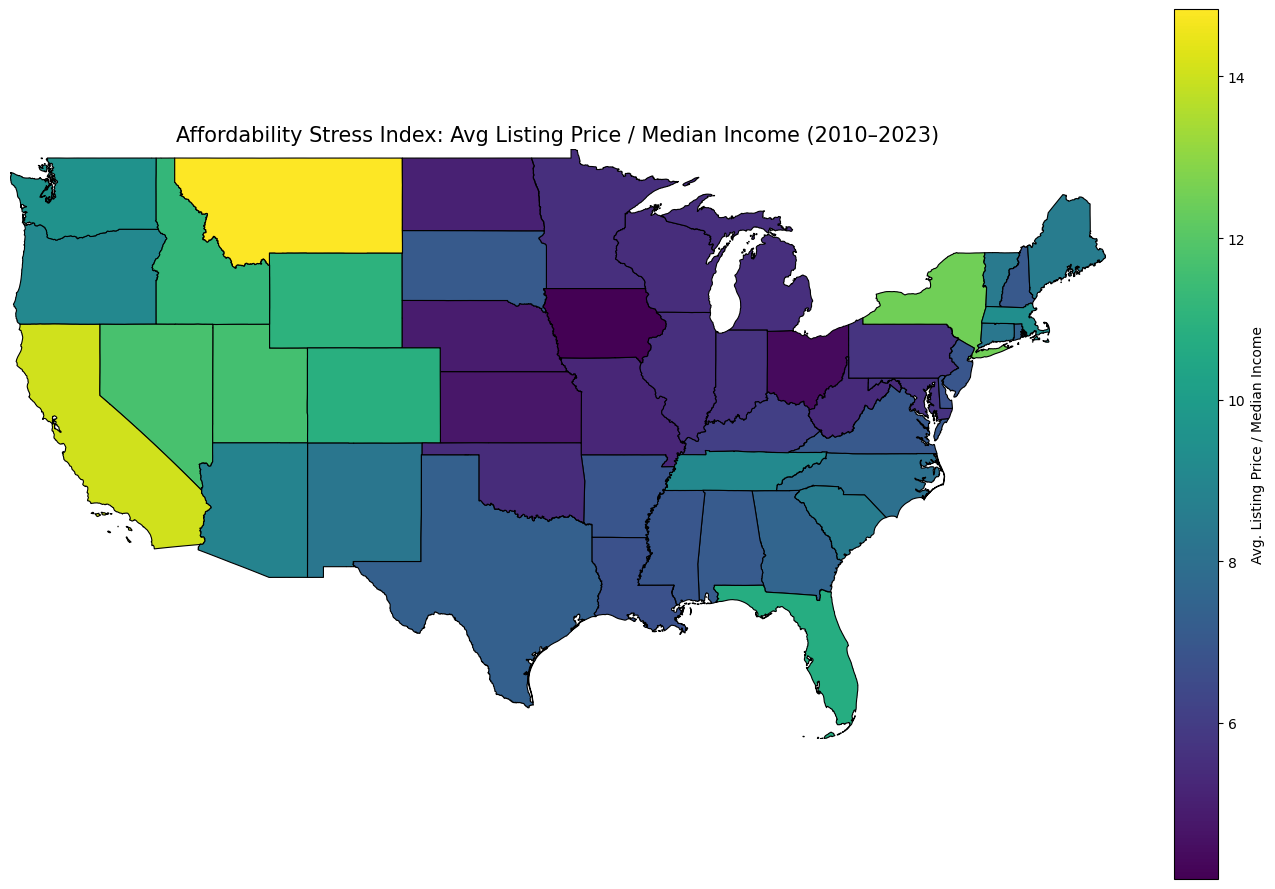

In [34]:
import geopandas as gpd
import matplotlib.pyplot as plt
import numpy as np

states = gpd.read_file("/Users/ziadsaad/Desktop/225 new project/eco225-project-zeyadsaad1/data/shapefiles/cb_2024_us_state_5m/cb_2024_us_state_5m.shp")
states = states[states["STUSPS"].isin(final_state["state_abbr"].unique())].copy()

drop = {"AK", "HI", "PR", "GU", "VI", "MP", "AS"}
states = states[~states["STUSPS"].isin(drop)].copy()

df2 = final_state.copy()
df2["affordability_stress"] = df2["avg_price"] / df2["median_income_mean"].replace(0, np.nan)

map_df2 = states.merge(df2, left_on="STUSPS", right_on="state_abbr", how="left")

# Plot
fig, ax = plt.subplots(1, 1, figsize=(14, 9))
map_df2.plot(
    column="affordability_stress",
    cmap="viridis",
    linewidth=0.8,
    edgecolor="black",
    legend=True,
    legend_kwds={"label": "Avg. Listing Price / Median Income"},
    ax=ax,
    missing_kwds={"color": "lightgrey", "edgecolor": "black", "hatch": "///", "label": "Missing"},
)

ax.set_title("Affordability Stress Index: Avg Listing Price / Median Income (2010–2023)", fontsize=15)
ax.axis("off")

xmin, ymin, xmax, ymax = map_df2.total_bounds
ax.set_xlim(xmin, xmax)
ax.set_ylim(ymin, ymax)

plt.tight_layout()
plt.show()

The final map shows a housing affordability stress index, constructed as the ratio of the average listing price to median household income, and aims to measure the relative burden of housing costs compared to local income levels. The map shows that affordability pressures are highest in Western states, particularly California, whereas in the Midwest, there is lower affordability stress. Areas with strong demand and supply constraints are likely to experience high prices and more affordability challenges.

## Regressions
The relationship between economic volatility and housing price growth could be either linear or nonlinear. Housing markets may reward investors for taking on local economic risk, which implies that areas with more volatile labor markets could generate higher housing returns as compensation for that uncertainty. This relationship, however, may not increase proportionally at all levels of volatility. Moderate levels of economic volatility could infer a dynamic labor market with strong growth potential, while extremely volatile local economies could discourage investment and weaken housing demand. To account for these possibilities, the regressions include both linear and nonlinear specifications for unemployment volatility. The nonlinear specification captures the possibility that housing returns may accelerate or decelerate as labor market volatility increases.

The regressions include several explanatory variables which are motivated by economic theory and housing market fundamentals. The main independent variable is unemployment volatility, measured as the standard deviation of the monthly unemployment rate between 2010 and 2023. This variable captures the level of economic risk within each state. The average unemployment rate is included to control for the overall strength of local labor markets, as higher unemployment levels may reduce housing demand. Median household income is included because income levels influence housing demand and purchasing power. Population serves as a proxy for market size and demographic pressure, since larger populations could generate stronger housing demand through migration and urban expansion.

Some housing market characteristics are also included. The average house size captures structural differences in housing supply, the share of ready-to-build listings reflects development conditions and new housing supply, and the number of listings measures market activity and housing market depth. Other specifications include housing price measures such as average listing price and price per square foot to account for differences in housing market structure across states.

Eight regressions are estimated to examine the relationship between unemployment volatility and housing price growth under different specifications. The first group of regressions focuses on baseline relationships and the addition of control variables and gradually introduce labor market, income, population, and housing supply variables. The second group of regressions explores alternative housing market controls and interaction effects.

In [45]:
import pandas as pd
import numpy as np
import statsmodels.formula.api as smf
from IPython.display import display, HTML
from stargazer.stargazer import Stargazer

# Prepare regression
df = final_state.copy()

reg_vars = [
    "hpi_growth_2010_2023",
    "unemp_volatility",
    "unemp_mean",
    "median_income_mean",
    "pop_mean",
    "avg_house_size",
    "share_ready_to_build",
    "avg_ppsf",
    "avg_price",
    "listings"
]

df = df[reg_vars].dropna().copy()

# Transformations
df["log_pop"] = np.log(df["pop_mean"])
df["log_listings"] = np.log(df["listings"])
df["log_income"] = np.log(df["median_income_mean"])
df["unemp_vol_sq"] = df["unemp_volatility"] ** 2

# High-income dummy
income_median = df["median_income_mean"].median()
df["high_income"] = (df["median_income_mean"] > income_median).astype(int)

df["unemp_vol_z"] = (df["unemp_volatility"] - df["unemp_volatility"].mean()) / df["unemp_volatility"].std()

# Table 1
# Benchmark
m0 = smf.ols(
    "hpi_growth_2010_2023 ~ unemp_volatility",
    data=df
).fit(cov_type="HC1")

# Regression 1
m1 = smf.ols(
    "hpi_growth_2010_2023 ~ unemp_volatility + unemp_mean + log_income + log_pop",
    data=df
).fit(cov_type="HC1")

# Regression 2
m2 = smf.ols(
    "hpi_growth_2010_2023 ~ unemp_volatility + unemp_mean + log_income + log_pop + avg_house_size + share_ready_to_build",
    data=df
).fit(cov_type="HC1")

# Regression 3
m3 = smf.ols(
    "hpi_growth_2010_2023 ~ unemp_volatility + unemp_mean + log_income + log_pop + avg_house_size + share_ready_to_build + log_listings",
    data=df
).fit(cov_type="HC1")

# Regression 4 (nonlinear)
m4 = smf.ols(
    "hpi_growth_2010_2023 ~ unemp_volatility + unemp_vol_sq + unemp_mean + log_income + log_pop + avg_house_size + share_ready_to_build",
    data=df
).fit(cov_type="HC1")

# Table 2
# Benchmark
m5_bench = smf.ols(
    "hpi_growth_2010_2023 ~ unemp_volatility + unemp_mean + log_income",
    data=df
).fit(cov_type="HC1")

# Regression 5
m5 = smf.ols(
    "hpi_growth_2010_2023 ~ unemp_volatility + unemp_mean + log_income + log_pop + avg_ppsf + share_ready_to_build",
    data=df
).fit(cov_type="HC1")

# Regression 6
m6 = smf.ols(
    "hpi_growth_2010_2023 ~ unemp_volatility + unemp_mean + log_income + log_pop + avg_price + avg_house_size",
    data=df
).fit(cov_type="HC1")

# Regression 7 (interaction with income level)
m7 = smf.ols(
    "hpi_growth_2010_2023 ~ unemp_volatility*high_income + unemp_mean + log_income + log_pop + avg_house_size + share_ready_to_build",
    data=df
).fit(cov_type="HC1")

# Regression 8 (interaction + market thickness)
m8 = smf.ols(
    "hpi_growth_2010_2023 ~ unemp_volatility*high_income + unemp_mean + log_income + log_pop + log_listings + avg_ppsf",
    data=df
).fit(cov_type="HC1")

### Regression Results

#### Model Equations

All regressions take the form:

$$Y_i = \beta_0 + \beta_1 \sigma_i + \mathbf{X}_i'\boldsymbol{\beta} + \varepsilon_i$$

where $Y_i$ is the cumulative log change in the FHFA House Price Index for state $i$ (2010–2023), $\sigma_i$ is unemployment volatility (standard deviation of monthly unemployment rates), and $\mathbf{X}_i$ is a vector of controls. Heteroskedasticity-robust (HC1) standard errors are used throughout.

**Benchmark**

$$Y_i = \beta_0 + \beta_1 \sigma_i + \varepsilon_i$$

**Full Baseline — Regression 3**

$$Y_i = \beta_0 + \beta_1 \sigma_i + \beta_2 \bar{u}_i + \beta_3 \ln(\text{Inc}_i) + \beta_4 \ln(\text{Pop}_i) + \beta_5 \text{Size}_i + \beta_6 \text{Build}_i + \beta_7 \ln(\text{List}_i) + \varepsilon_i$$

**Nonlinear Specification — Regression 4**

$$Y_i = \beta_0 + \beta_1 \sigma_i + \beta_2 \sigma_i^2 + \beta_3 \bar{u}_i + \beta_4 \ln(\text{Inc}_i) + \beta_5 \ln(\text{Pop}_i) + \beta_6 \text{Size}_i + \beta_7 \text{Build}_i + \varepsilon_i$$

**Preferred Specification — Regression 8**

$$Y_i = \beta_0 + \beta_1 \sigma_i + \beta_2 (\sigma_i \times \mathbb{1}_{\text{HighInc}_i}) + \beta_3 \mathbb{1}_{\text{HighInc}_i} + \beta_4 \bar{u}_i + \beta_5 \ln(\text{Inc}_i) + \beta_6 \ln(\text{Pop}_i) + \beta_7 \ln(\text{List}_i) + \beta_8 \text{PPSF}_i + \varepsilon_i$$

| Symbol | Variable |
|---|---|
| $\sigma_i$ | Unemployment volatility (std. dev. of monthly unemployment rate) |
| $\sigma_i^2$ | Unemployment volatility squared |
| $\bar{u}_i$ | Average unemployment rate |
| $\ln(\text{Inc}_i)$ | Log median household income |
| $\ln(\text{Pop}_i)$ | Log population |
| $\text{Size}_i$ | Average house size (sq. ft.) |
| $\text{Build}_i$ | Share of ready-to-build listings |
| $\ln(\text{List}_i)$ | Log number of listings |
| $\text{PPSF}_i$ | Average price per sq. ft. |
| $\mathbb{1}_{\text{HighInc}_i}$ | Indicator: state above median income |

In [46]:
# Table 1
table1_models = [m0, m1, m2, m3, m4]

stargazer1 = Stargazer(table1_models)
stargazer1.dependent_variable_name("Housing price growth (log change, 2010–2023)")
stargazer1.title("Table 2. Housing Price Growth and Unemployment Volatility: Baseline and Nonlinear Specifications")
stargazer1.custom_columns(["Benchmark", "Reg 1", "Reg 2", "Reg 3", "Reg 4"], [1,1,1,1,1])

stargazer1.rename_covariates({
    "Intercept": "Constant",
    "unemp_volatility": "Unemployment volatility (std. dev., pp)",
    "unemp_vol_sq": "Unemployment volatility squared (pp²)",
    "unemp_mean": "Average unemployment rate (pp)",
    "log_income": "Log median household income (log $)",
    "log_pop": "Log population (log persons)",
    "avg_house_size": "Average house size (sq. ft.)",
    "share_ready_to_build": "Share of ready-to-build listings (0–1)",
    "log_listings": "Log number of listings (log count)",
})

stargazer1.show_degrees_of_freedom(False)
stargazer1.significant_digits(3)
stargazer1.covariate_order([
    "unemp_volatility",
    "unemp_vol_sq",
    "unemp_mean",
    "log_income",
    "log_pop",
    "avg_house_size",
    "share_ready_to_build",
    "log_listings",
    "Intercept"
])

stargazer1.add_custom_notes([
    "Dependent variable: log change in FHFA House Price Index (2010–2023).",
    "Robust standard errors in parentheses."
])

display(HTML(stargazer1.render_html()))

Table 2 presents baseline and nonlinear regression specifications, examining the relationship between unemployment volatility and housing price growth. The specification progressively introduces labor market, income, and housing supply controls.

In [47]:
# Table 2
table2_models = [m5_bench, m5, m6, m7, m8]

stargazer2 = Stargazer(table2_models)
stargazer2.dependent_variable_name("Housing price growth (log change, 2010–2023)")
stargazer2.title("Table 3. Housing Price Growth and Unemployment Volatility: Alternative Controls and Interaction Specifications")
stargazer2.custom_columns(["Benchmark", "Reg 5", "Reg 6", "Reg 7", "Reg 8"], [1,1,1,1,1])

stargazer2.rename_covariates({
    "Intercept": "Constant",
    "unemp_volatility": "Unemployment volatility (std. dev., pp)",
    "unemp_volatility:high_income": "Volatility × high-income (std. dev., pp)",
    "high_income": "High-income state (0/1)",
    "unemp_mean": "Average unemployment rate (pp)",
    "log_income": "Log median household income (log $)",
    "log_pop": "Log population (log persons)",
    "avg_house_size": "Average house size (sq. ft.)",
    "share_ready_to_build": "Share of ready-to-build listings (0–1)",
    "avg_ppsf": "Average price per sq. ft. ($)",
    "avg_price": "Average listing price ($)",
    "log_listings": "Log number of listings (log count)",
})

stargazer2.show_degrees_of_freedom(False)
stargazer2.significant_digits(3)
stargazer2.covariate_order([
    "unemp_volatility",
    "unemp_volatility:high_income",
    "high_income",
    "unemp_mean",
    "log_income",
    "log_pop",
    "avg_house_size",
    "share_ready_to_build",
    "avg_ppsf",
    "avg_price",
    "log_listings",
    "Intercept"
])

stargazer2.add_custom_notes([
    "Dependent variable: log change in FHFA House Price Index (2010–2023).",
    "Robust standard errors in parentheses."
])

display(HTML(stargazer2.render_html()))

Table 3 introduces alternative housing market controls and interaction specifications, aimed at exploring whether the effect of economic volatility varies across different economic conditions.

### Interpretation of the Results
The regression results suggest a consistent positive relationship between unemployment volatility and housing price growth across most specifications. In the baseline regression, the coefficient on unemployment volatility is positive and statistically significant, which indicates that states with more volatile labor markets tend to experience higher long-run housing appreciation. When additional control variables are added, the positive relationship between unemployment volatility and housing price growth remains relatively stable. This suggests that the association is not solely driven by differences in income, population size, or housing supply conditions.

The nonlinear specification indicates that the relationship between volatility and housing returns may change at higher levels of volatility. The positive coefficient on the squared volatility term suggests that housing price growth may increase more rapidly as economic volatility increases past moderate levels. The negative coefficient on the interaction between unemployment volatility and high-income states indicates that the positive effect of volatility on housing price growth is weaker in states with higher income levels.

Overall, the results suggest that economic volatility plays an important role in shaping housing price dynamics. States with more volatile labor markets tend to experience higher housing appreciation, consistent with the hypothesis that housing markets may compensate investors for economic risk. However, the strength of this relationship varies depending on income levels and housing market characteristics.

### Preferred Specification
The preferred specification is Regression 8 in Table 3. This model includes unemployment volatility, labor market controls, housing market characteristics, and an interaction term between unemployment volatility and high-income states. This specification is chosen because it has a strong representation of both economic risk and housing market conditions while still maintaining strong explanatory power. Regression 8 has the highest R-squared among all the models, with an R-squared of approximately 0.48 and an adjusted R-squared of 0.37. The interaction terms also allow the model to capture heterogeneity in the relationship between economic volatility and housing returns.

### Evaluating the Regressions
The R-squared statistic measures the proportion of variation in housing price growth explained by the independent variables. As additional controls and interaction terms are introduced, the R-squared increases from approximately 0.24 in the baseline model to 0.48. This indicates that the explanatory variables capture more of the variation in housing price appreciation across states. Adjusted R-squared is used to account for the number of explanatory variables included in the model, these values also showed a similar improvement across specifications, suggesting that the added variables have meaningful explanatory power. The F-statistics across the models indicate that the regressions are jointly significant, meaning that the explanatory variables together help explain variation in housing price growth.

### What We Learn From the Regressions
The regression results provide evidence that supports the hypothesis that economic risk may be related to housing returns. While the relationship is not perfectly linear and varies across specifications, the positive association between unemployment volatility and housing price growth appears across multiple models. These findings suggest that housing markets may have a risk-return tradeoff similar to financial markets. Areas with more volatile economies may offer higher potential housing returns, although these returns could also come with more uncertainty and variation.

### New Regression (With UHaul Data)

In [83]:
import pandas as pd
import numpy as np
import statsmodels.formula.api as smf
from IPython.display import display, HTML
from stargazer.stargazer import Stargazer

df = pd.read_csv("/Users/ziadsaad/Desktop/225 new project/eco225-project-zeyadsaad1/notebooks/output/final_state_with_migration_clean.csv")

# Transformations
df["log_pop"]      = np.log(df["pop_mean"])
df["log_listings"] = np.log(df["listings"])
df["log_income"]   = np.log(df["median_income_mean"])
df["unemp_vol_sq"] = df["unemp_volatility"] ** 2
income_median      = df["median_income_mean"].median()
df["high_income"]  = (df["median_income_mean"] > income_median).astype(int)

# Drop rows
reg_vars = [
    "hpi_growth_2010_2023",
    "unemp_volatility", "unemp_vol_sq", "unemp_mean",
    "log_income", "log_pop", "log_listings", "avg_ppsf",
    "high_income", "net_migration_mean", "net_migration_vol"
]
df = df[reg_vars].dropna().copy()

# Preferred spec
m_bench = smf.ols(
    "hpi_growth_2010_2023 ~ unemp_volatility * high_income"
    " + unemp_mean + log_income + log_pop + log_listings + avg_ppsf",
    data=df
).fit(cov_type="HC1")

# Reg A
m_a = smf.ols(
    "hpi_growth_2010_2023 ~ unemp_volatility * high_income"
    " + unemp_mean + log_income + log_pop + log_listings + avg_ppsf"
    " + net_migration_mean",
    data=df
).fit(cov_type="HC1")

# Reg B
m_b = smf.ols(
    "hpi_growth_2010_2023 ~ unemp_volatility * high_income"
    " + unemp_mean + log_income + log_pop + log_listings + avg_ppsf"
    " + net_migration_vol",
    data=df
).fit(cov_type="HC1")

# Reg C
m_c = smf.ols(
    "hpi_growth_2010_2023 ~ unemp_volatility * high_income"
    " + unemp_mean + log_income + log_pop + log_listings + avg_ppsf"
    " + net_migration_mean + net_migration_vol",
    data=df
).fit(cov_type="HC1")

# Reg D
m_d = smf.ols(
    "hpi_growth_2010_2023 ~ unemp_volatility * high_income"
    " + unemp_volatility * net_migration_mean"
    " + unemp_mean + log_income + log_pop + log_listings + avg_ppsf"
    " + net_migration_vol",
    data=df
).fit(cov_type="HC1")

stargazer = Stargazer([m_bench, m_a, m_b, m_c, m_d])
stargazer.dependent_variable_name("Housing price growth (log change, 2010\u20132023)")
stargazer.title("Table 4. Housing Price Growth with U-Haul Migration Controls")
stargazer.custom_columns(["Benchmark", "Reg A", "Reg B", "Reg C", "Reg D"], [1,1,1,1,1])

stargazer.rename_covariates({
    "Intercept":                        "Constant",
    "unemp_volatility":                 "Unemployment volatility (std. dev., pp)",
    "unemp_volatility:high_income":     "Volatility \u00d7 high-income (pp)",
    "unemp_volatility:net_migration_mean": "Volatility \u00d7 net migration (pp \u00d7 %)",
    "high_income":                      "High-income state (0/1)",
    "unemp_mean":                       "Average unemployment rate (pp)",
    "log_income":                       "Log median household income (log $)",
    "log_pop":                          "Log population (log persons)",
    "log_listings":                     "Log number of listings (log count)",
    "avg_ppsf":                         "Average price per sq. ft. ($)",
    "net_migration_mean":               "Net migration, mean (%, 2015\u20132023)",
    "net_migration_vol":                "Net migration, volatility (std. dev., %)",
})

stargazer.show_degrees_of_freedom(False)
stargazer.significant_digits(3)
stargazer.covariate_order([
    "unemp_volatility",
    "unemp_volatility:high_income",
    "unemp_volatility:net_migration_mean",
    "high_income",
    "net_migration_mean",
    "net_migration_vol",
    "unemp_mean",
    "log_income",
    "log_pop",
    "log_listings",
    "avg_ppsf",
    "Intercept",
])

stargazer.add_custom_notes([
    "Dependent variable: log change in FHFA House Price Index (2010\u20132023).",
    "Migration variables from U-Haul Growth Index, averaged 2015\u20132023.",
    "Robust standard errors (HC1) in parentheses.",
])

display(HTML(stargazer.render_html()))

This regression table incorporates the new U-Haul variables and produces an R² of around 0.69, which fits the data substantially better when compared with the previous regressions' R² of 0.21-0.47. This suggests that the additional controls explain more of the variation in housing returns. The main finding still holds across all the regressions: unemployment volatility has a positive and statistically significant effect on housing price growth, and this relationship weakens in high-income states.

# Final Project
## Potential Data to Scrape
The U-Haul Migration Trends Growth Index provides state-level domestic migration data derived from real moving transactions, making it a useful proxy for population demand shifts across U.S. states. This data strengthens the research because migration flows directly affect housing demand and can independently drive up prices, and without controlling for this, any observed relationship between labor market volatility and housing returns could risk reflecting demand-side factors rather than an actual risk premium.

The data is sourced from https://www.uhaul.com/About/Migration/, where U-Haul reports in-migration percentage, out-migration percentage, and a growth rank for each state. It cannot be downloaded directly since values are rendered one state and year at a time through a dropdown menu, with no CSV or Excel export available. Scraping is therefore necessary to extract these values systematically across all 50 states from 2015 (earliest year available) to 2023.

The scraped data will be merged with my existing dataset using state and year as identifiers, adding three new variables: in-migration rate, out-migration rate, and net migration. These variables will enter the regression as controls, allowing the model to isolate the effect of labor market volatility on housing returns after accounting for migration-driven demand.

## Potential Challenges
The primary challenge with this source is its dynamic structure. The data is not loaded on a single page, but rendered through a dropdown menu that requires selecting a specific state and year. This means a standard static scraper would fail, and the script needs to simulate user interactions to cycle through all 50 states across 8 years. Since the data is annual and the historical range (2015–2023) is already available on the site, there is no need to run the scraper repeatedly over time. A single run was sufficient to capture the complete dataset, and the scrape has already been completed successfully.

No significant access barriers were encountered: the site requires no login, has no paywalls, and did not block automated requests during extraction. All three target variables (in-migration rate, out-migration rate, and growth rank) were successfully scraped for all 50 states across the full time period, producing a panel dataset ready for merging.

## Scraping Data from a Website

In [ ]:
import re
import time
import pandas as pd

from selenium import webdriver
from selenium.webdriver.common.by import By
from selenium.webdriver.chrome.service import Service
from selenium.webdriver.support.ui import WebDriverWait, Select
from selenium.webdriver.support import expected_conditions as EC
from webdriver_manager.chrome import ChromeDriverManager


URL = "https://www.uhaul.com/About/Migration/"

YEARS = [str(y) for y in range(2010, 2024)]

STATES = {
    "AL": "Alabama",
    "AK": "Alaska",
    "AZ": "Arizona",
    "AR": "Arkansas",
    "CA": "California",
    "CO": "Colorado",
    "CT": "Connecticut",
    "DE": "Delaware",
    "FL": "Florida",
    "GA": "Georgia",
    "HI": "Hawaii",
    "ID": "Idaho",
    "IL": "Illinois",
    "IN": "Indiana",
    "IA": "Iowa",
    "KS": "Kansas",
    "KY": "Kentucky",
    "LA": "Louisiana",
    "ME": "Maine",
    "MD": "Maryland",
    "MA": "Massachusetts",
    "MI": "Michigan",
    "MN": "Minnesota",
    "MS": "Mississippi",
    "MO": "Missouri",
    "MT": "Montana",
    "NE": "Nebraska",
    "NV": "Nevada",
    "NH": "New Hampshire",
    "NJ": "New Jersey",
    "NM": "New Mexico",
    "NY": "New York",
    "NC": "North Carolina",
    "ND": "North Dakota",
    "OH": "Ohio",
    "OK": "Oklahoma",
    "OR": "Oregon",
    "PA": "Pennsylvania",
    "RI": "Rhode Island",
    "SC": "South Carolina",
    "SD": "South Dakota",
    "TN": "Tennessee",
    "TX": "Texas",
    "UT": "Utah",
    "VT": "Vermont",
    "VA": "Virginia",
    "WA": "Washington",
    "WV": "West Virginia",
    "WI": "Wisconsin",
    "WY": "Wyoming",
}


def extract_field(text: str, label: str) -> str | None:
    """
    Extract the line immediately after a label like 'In-migration:'.
    """
    pattern = rf"{re.escape(label)}\s*\n([^\n]+)"
    match = re.search(pattern, text, flags=re.IGNORECASE)
    return match.group(1).strip() if match else None


def parse_percent(value: str | None) -> float | None:
    if value is None:
        return None
    value = value.replace("%", "").strip()
    try:
        return float(value)
    except ValueError:
        return None


def parse_int(value: str | None) -> int | None:
    if value is None:
        return None
    value = re.sub(r"[^\d]", "", value)
    try:
        return int(value)
    except ValueError:
        return None


def scrape_one(driver, wait, year: str, state_abbr: str, state_name: str) -> dict:
    driver.get(URL)

    year_elem = wait.until(EC.presence_of_element_located((By.ID, "usYear")))
    state_elem = wait.until(EC.presence_of_element_located((By.ID, "usState")))

    Select(year_elem).select_by_visible_text(year)
    Select(state_elem).select_by_visible_text(state_name)

    continue_btn = wait.until(
        EC.element_to_be_clickable((By.XPATH, "//button[contains(., 'Continue')]"))
    )
    driver.execute_script("arguments[0].click();", continue_btn)

    # Wait until the chosen state appears in the results area/body text.
    wait.until(lambda d: state_name in d.find_element(By.TAG_NAME, "body").text)

    time.sleep(2)
    body_text = driver.find_element(By.TAG_NAME, "body").text

    growth_rank = parse_int(extract_field(body_text, "Growth State Rank:"))
    in_migration = parse_percent(extract_field(body_text, "In-migration:"))
    out_migration = parse_percent(extract_field(body_text, "Out-migration:"))
    leading_cities = extract_field(body_text, "Leading U.S. Growth Cities:")

    return {
        "year": int(year),
        "state": state_name,
        "state_abbr": state_abbr,
        "growth_rank": growth_rank,
        "in_migration_pct": in_migration,
        "out_migration_pct": out_migration,
        "leading_cities": leading_cities,
    }


def main():
    driver = webdriver.Chrome(service=Service(ChromeDriverManager().install()))
    wait = WebDriverWait(driver, 20)

    results = []
    failed = []

    try:
        for year in YEARS:
            for abbr, state_name in STATES.items():
                print(f"Scraping {year} - {state_name}")
                try:
                    row = scrape_one(driver, wait, year, abbr, state_name)
                    results.append(row)
                    time.sleep(1)
                except Exception as e:
                    print(f"FAILED: {year} - {state_name} -> {e}")
                    failed.append(
                        {
                            "year": year,
                            "state": state_name,
                            "state_abbr": abbr,
                            "error": str(e),
                        }
                    )

        df = pd.DataFrame(results)
        df["net_migration_pct"] = df["in_migration_pct"] - df["out_migration_pct"]

        df.to_csv("uhaul_migration_2010_2023.csv", index=False)
        print(f"\nSaved {len(df)} rows to uhaul_migration_2010_2023.csv")

        if failed:
            fail_df = pd.DataFrame(failed)
            fail_df.to_csv("uhaul_scrape_failures.csv", index=False)

    finally:
        driver.quit()


if __name__ == "__main__":
    main()

The script uses Selenium to automate a Chrome browser, navigating to the U-Haul migration page and selecting each combination of state and year from the dropdown menus, simulating what a user would do manually. After clicking "Continue," it waits for the page to load and extracts the relevant text from the page body, parsing out in-migration percentage, out-migration percentage, and growth rank. This process loops across all 50 states and all available years (2015–2023). Net migration is computed as the difference between in-migration and out-migration before the full dataset is exported to a CSV file. A one-second delay is built in between requests to avoid overloading the server, and any failed attempts are logged separately.

## Visualizing the Scraped Dataset

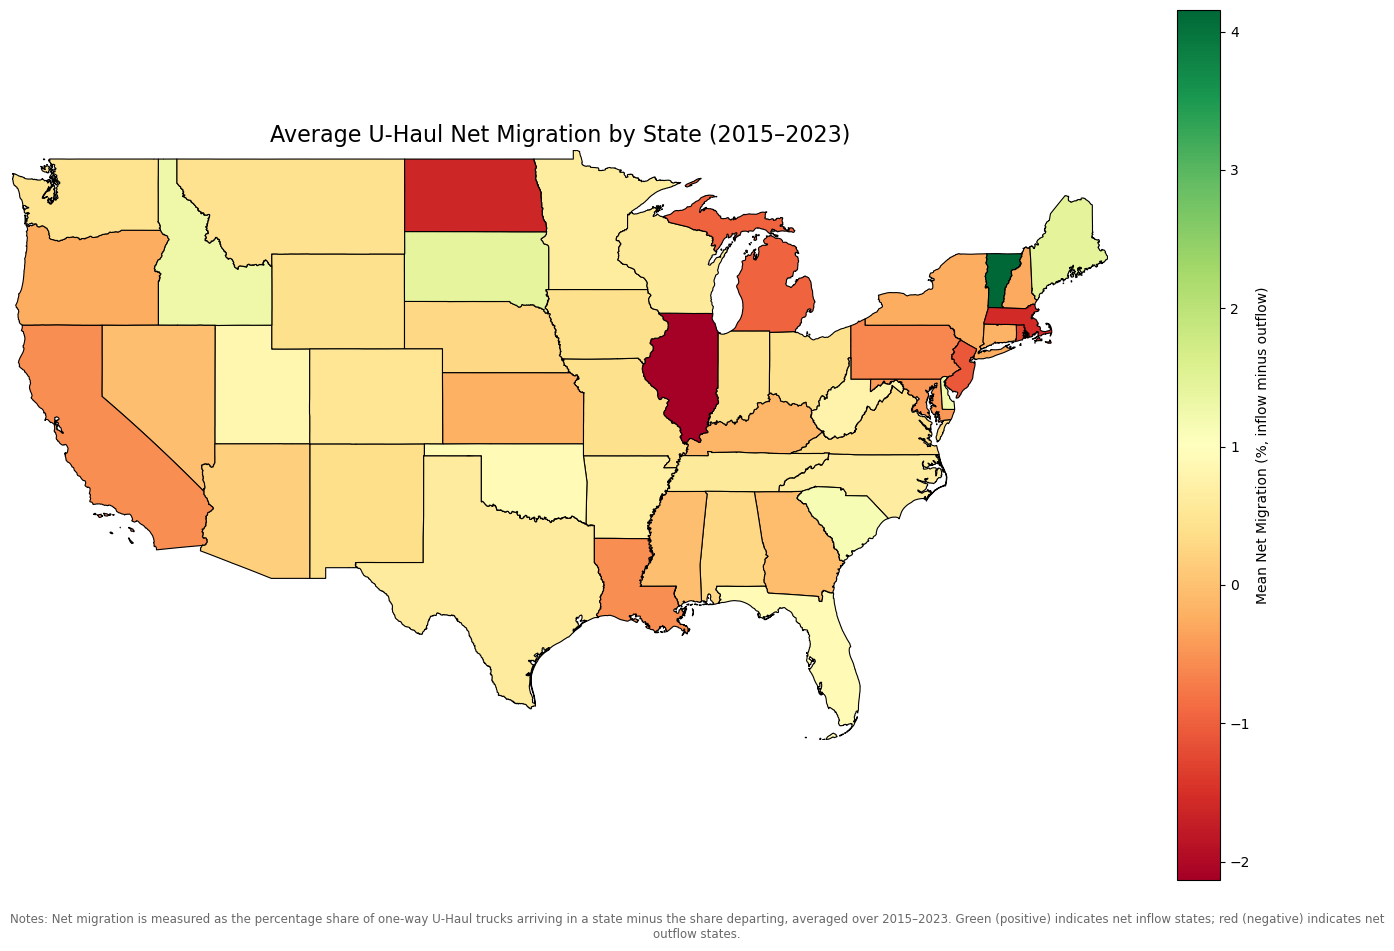

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import geopandas as gpd

UHAUL_PATH = "/Users/ziadsaad/Desktop/225 new project/eco225-project-zeyadsaad1/uhaul_scrape/uhaul_migration_final.csv"
SHP_PATH   = "/Users/ziadsaad/Desktop/225 new project/eco225-project-zeyadsaad1/data/shapefiles/cb_2024_us_state_5m/cb_2024_us_state_5m.shp"
FINAL_PATH = "/Users/ziadsaad/Desktop/225 new project/eco225-project-zeyadsaad1/notebooks/output/final_state_with_migration_clean.csv"

uhaul = pd.read_csv(UHAUL_PATH)
final = pd.read_csv(FINAL_PATH)

# State-level averages
state_avg = (
    uhaul.groupby("state_abbr", as_index=False)
         .agg(net_migration_mean=("net_migration_pct", "mean"),
              in_migration_mean=("in_migration_pct", "mean"),
              out_migration_mean=("out_migration_pct", "mean"))
)

# Figure 1: map of average net migration (2015–2023)
states = gpd.read_file(SHP_PATH)
drop = {"AK", "HI", "PR", "GU", "VI", "MP", "AS"}
states = states[~states["STUSPS"].isin(drop)].copy()
states = states[states["STUSPS"].isin(state_avg["state_abbr"])].copy()

map_df = states.merge(state_avg, left_on="STUSPS", right_on="state_abbr", how="left")

fig1, ax1 = plt.subplots(1, 1, figsize=(14, 9))
map_df.plot(
    column="net_migration_mean",
    cmap="RdYlGn",
    linewidth=0.8,
    edgecolor="black",
    legend=True,
    legend_kwds={"label": "Mean Net Migration (%, inflow minus outflow)"},
    ax=ax1,
    missing_kwds={"color": "lightgrey", "edgecolor": "black", "hatch": "///", "label": "Missing"},
)
ax1.set_title("Average U-Haul Net Migration by State (2015\u20132023)", fontsize=16)
ax1.axis("off")
xmin, ymin, xmax, ymax = map_df.total_bounds
ax1.set_xlim(xmin, xmax)
ax1.set_ylim(ymin, ymax)

note1 = ("Notes: Net migration is measured as the percentage share of one-way U-Haul trucks arriving in a state "
         "minus the share departing, averaged over 2015\u20132023. Green (positive) indicates net inflow states; "
         "red (negative) indicates net outflow states.")
fig1.text(0.5, -0.02, note1, ha="center", va="top", fontsize=8.5, color="dimgray", wrap=True)
plt.subplots_adjust(bottom=0.1)
plt.tight_layout()
plt.show()

The map displays average net migration by state from 2015–2023, where green indicates net inflows and red indicates net outflows, capturing the demand-side housing pressure. Illinois and North Dakota show clear outflows, and California's negative reading aligns with post-2018 emigration trends. However, Massachusetts and Vermont appearing as top in-migration states, and Texas and Florida as near-neutral, are counterintuitive and could reflect a limitation of U-Haul data. Low transaction volumes in smaller states could be producing big swings from relatively few moves.

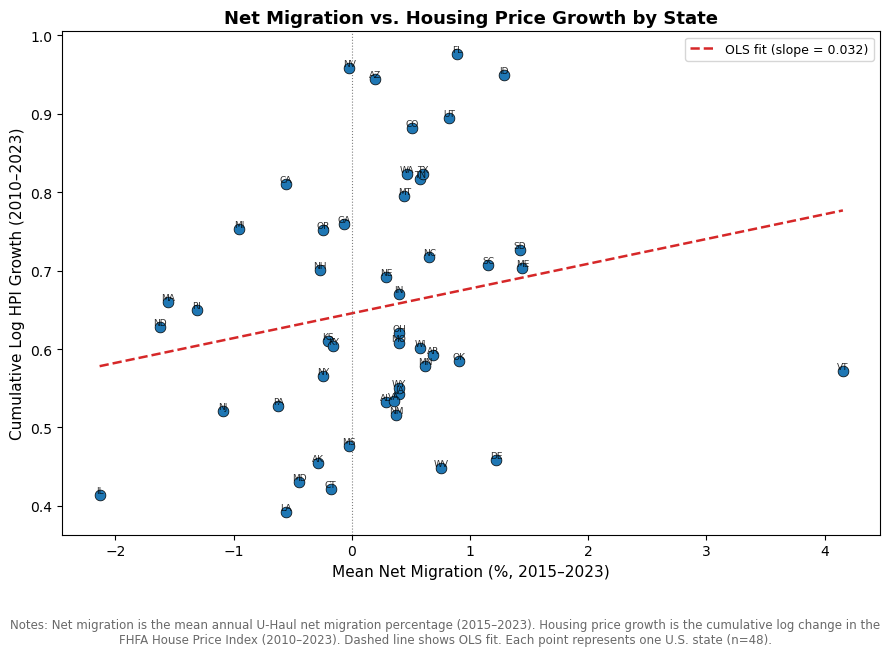

In [ ]:
# Figure 2: Scatter net migration vs HPI growth
scatter_df = final[["state_abbr", "net_migration_mean", "hpi_growth_2010_2023"]].dropna()

fig2, ax2 = plt.subplots(figsize=(9, 6))

ax2.scatter(
    scatter_df["net_migration_mean"],
    scatter_df["hpi_growth_2010_2023"],
    color="#1f77b4", s=60, edgecolor="black", linewidth=0.5, zorder=3
)

# Annotate each state
for _, row in scatter_df.iterrows():
    ax2.annotate(row["state_abbr"],
                 (row["net_migration_mean"], row["hpi_growth_2010_2023"]),
                 fontsize=6.5, ha="center", va="bottom", alpha=0.8)

# OLS fit line
m, b = np.polyfit(scatter_df["net_migration_mean"], scatter_df["hpi_growth_2010_2023"], 1)
x_line = np.linspace(scatter_df["net_migration_mean"].min(), scatter_df["net_migration_mean"].max(), 100)
ax2.plot(x_line, m * x_line + b, color="#d62728", linewidth=1.8,
         linestyle="--", label="OLS fit (slope = {:.3f})".format(m))

ax2.axvline(0, color="gray", linewidth=0.8, linestyle=":")
ax2.set_xlabel("Mean Net Migration (%, 2015\u20132023)", fontsize=11)
ax2.set_ylabel("Cumulative Log HPI Growth (2010\u20132023)", fontsize=11)
ax2.set_title("Net Migration vs. Housing Price Growth by State", fontsize=13, fontweight="bold")
ax2.legend(fontsize=9)

note2 = ("Notes: Net migration is the mean annual U-Haul net migration percentage (2015\u20132023). "
         "Housing price growth is the cumulative log change in the FHFA House Price Index (2010\u20132023). "
         "Dashed line shows OLS fit. Each point represents one U.S. state (n=48).")
fig2.text(0.5, -0.04, note2, ha="center", va="top", fontsize=8.5, color="dimgray", wrap=True)
plt.subplots_adjust(bottom=0.15)
plt.tight_layout()
plt.show()

The scatter plot shows that states with higher net in-migration tend to have slightly higher housing price growth, which is expected. However, the relationship is weak and there is a lot of scatter around the trend line, meaning migration alone does not explain much of the variation in housing returns, which is why it is a control variable rather than a key explanatory one. Vermont is an outlier, which reflects the data quality issue discussed earlier.

## Regression Tree

### Dataset Choice

An expanded state-year panel dataset (with 441 observations) was considered for the ML section, but turned out to be unsuitable for the regression tree. The pandemic housing boom created a dominant common time shock, where year dummies consumed 91% of the tree's splitting capacity, leaving no room for the economic features of interest. Year-demeaning the target to remove the time shock was attempted, but the tree instead latched onto permanent state-level characteristics (existing price levels, population size) with zero importance assigned to unemployment volatility and migration, which are the variables central to the research question. Because the research question is about cross-state differences in long-run housing appreciation, the original 49-state cross-section has been chosen as the appropriate dataset for the ML models.

### Objective Function

The regression tree recursively partitions the feature space by finding the variable and split threshold that minimize the within-node mean squared error of housing price growth. At each node, the algorithm solves:

$$\underset{j,\, s}{\min} \left[ \sum_{i:\, x_{ij} < s} \left( y_i - \bar{y}_{L} \right)^2 + \sum_{i:\, x_{ij} \geq s} \left( y_i - \bar{y}_{R} \right)^2 \right]$$

where:

| Symbol | Meaning |
|---|---|
| $y_i$ | Cumulative log HPI growth (2010–2023) for state $i$ |
| $x_{ij}$ | Value of feature $j$ for state $i$ (see features below) |
| $j$ | Feature chosen to split on at this node |
| $s$ | Candidate split threshold for feature $j$ |
| $\bar{y}_L$ | Mean HPI growth for states with $x_{ij} < s$ (left child) |
| $\bar{y}_R$ | Mean HPI growth for states with $x_{ij} \geq s$ (right child) |

**Features $\mathbf{x}_i$**:

| Feature | Description |
|---|---|
| `unemp_volatility` | Std. dev. of monthly unemployment rate (pp) |
| `unemp_mean` | Average unemployment rate (pp) |
| `log_income` | Log median household income (log $) |
| `log_pop` | Log population (log persons) |
| `log_listings` | Log number of listings (log count) |
| `avg_ppsf` | Average price per sq. ft. ($) |
| `net_migration_mean` | Mean net U-Haul migration (%, 2015–2023) |
| `net_migration_vol` | Std. dev. of net migration (%) |

The main regularization parameter is max_depth=3, which limits the tree to at most 3 splits. Increasing it lets the tree fit the training data more, but risks overfitting. Decreasing it produces a simpler model that could miss important patterns.

In-sample MSE : 0.00853
In-sample R²  : 0.647

Feature importances:
avg_ppsf              0.579923
net_migration_vol     0.166770
net_migration_mean    0.133019
log_income            0.080062
unemp_volatility      0.040226
unemp_mean            0.000000
log_pop               0.000000
log_listings          0.000000


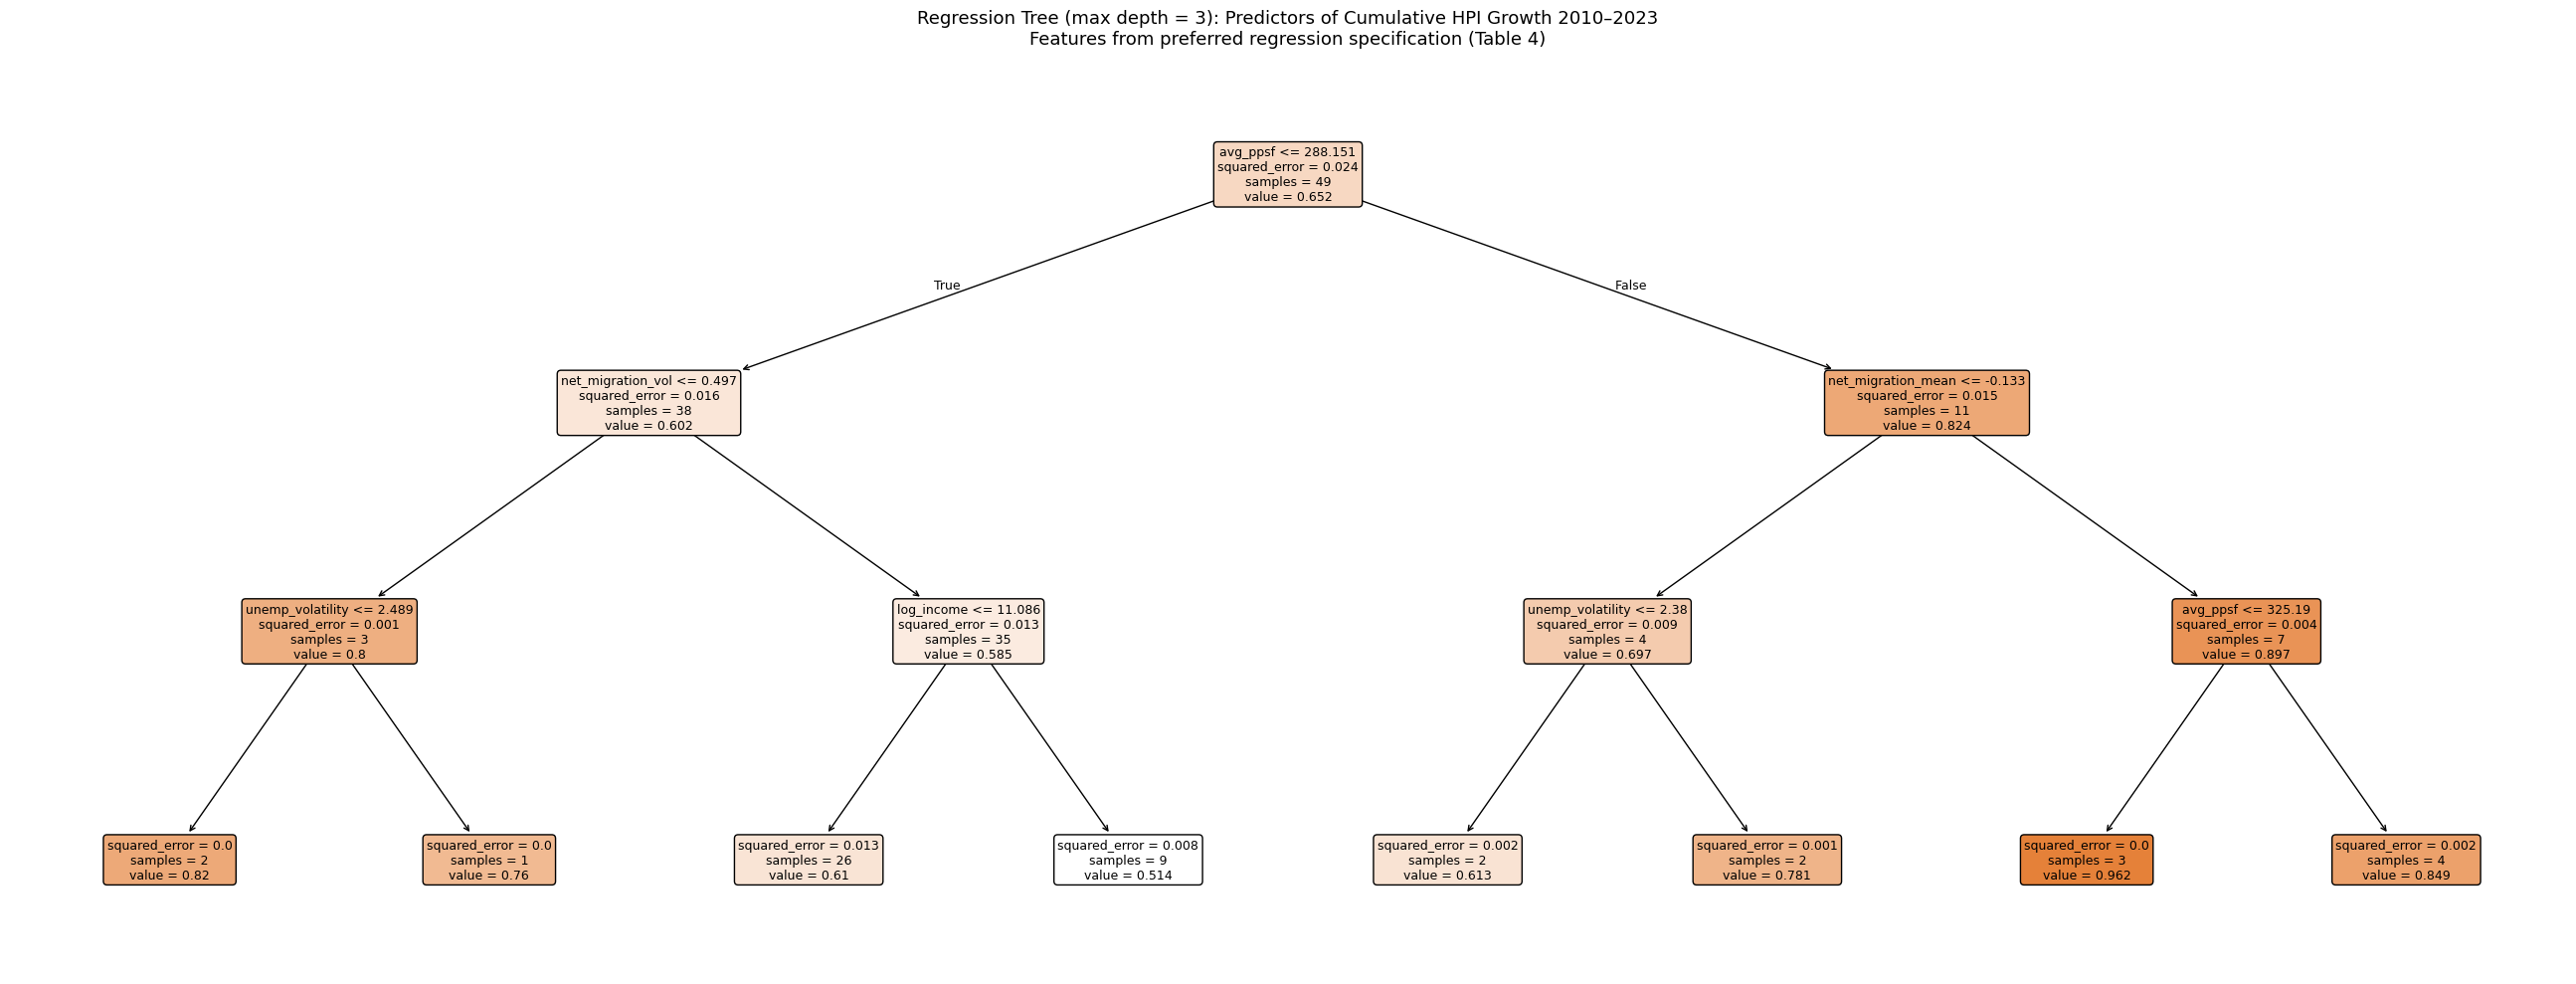

In [ ]:
import pandas as pd
import numpy as np
from sklearn import tree, metrics
import matplotlib.pyplot as plt

df = pd.read_csv("/Users/ziadsaad/Desktop/225 new project/eco225-project-zeyadsaad1/notebooks/output/final_state_with_migration_clean.csv")

df["log_pop"]      = np.log(df["pop_mean"])
df["log_listings"] = np.log(df["listings"])
df["log_income"]   = np.log(df["median_income_mean"])

FEATURES = [
    "unemp_volatility",   
    "unemp_mean",         
    "log_income",         
    "log_pop",            
    "log_listings",       
    "avg_ppsf",           
    "net_migration_mean", 
    "net_migration_vol",  
]

tree_df = df[FEATURES + ["hpi_growth_2010_2023"]].dropna().copy()
X = tree_df[FEATURES]
y = tree_df["hpi_growth_2010_2023"]

reg_tree = tree.DecisionTreeRegressor(max_depth=3, random_state=42).fit(X, y)

y_pred = reg_tree.predict(X)
print("In-sample MSE : {:.5f}".format(metrics.mean_squared_error(y, y_pred)))
print("In-sample R\u00b2  : {:.3f}".format(metrics.r2_score(y, y_pred)))
print("\nFeature importances:")
importances = pd.Series(reg_tree.feature_importances_, index=FEATURES).sort_values(ascending=False)
print(importances.to_string())

# Plot tree
fig, ax = plt.subplots(figsize=(26, 10))
tree.plot_tree(
    reg_tree,
    feature_names=FEATURES,
    filled=True,
    rounded=True,
    fontsize=9,
    ax=ax
)
ax.set_title(
    "Regression Tree (max depth = 3): Predictors of Cumulative HPI Growth 2010\u20132023\n"
    "Features from preferred regression specification (Table 4)",
    fontsize=13, pad=12
)
plt.tight_layout()
plt.show()

This tree shows that migration and existing price structure are the strongest predictors of long-run housing appreciation, with unemployment volatility playing a secondary but present role. States with already-expensive housing appreciated more, which is a structural supply/demand characteristic, not a shock. The UHaul migration variables are the second most important signal, outperforming every other economic feature.

Kitchen Sink Tree
In-sample MSE : 0.00041
In-sample R²  : 0.983

Feature importances:
hpi_yoy_mean    0.991058
hpi_yoy_vol     0.005477
log_listings    0.003465


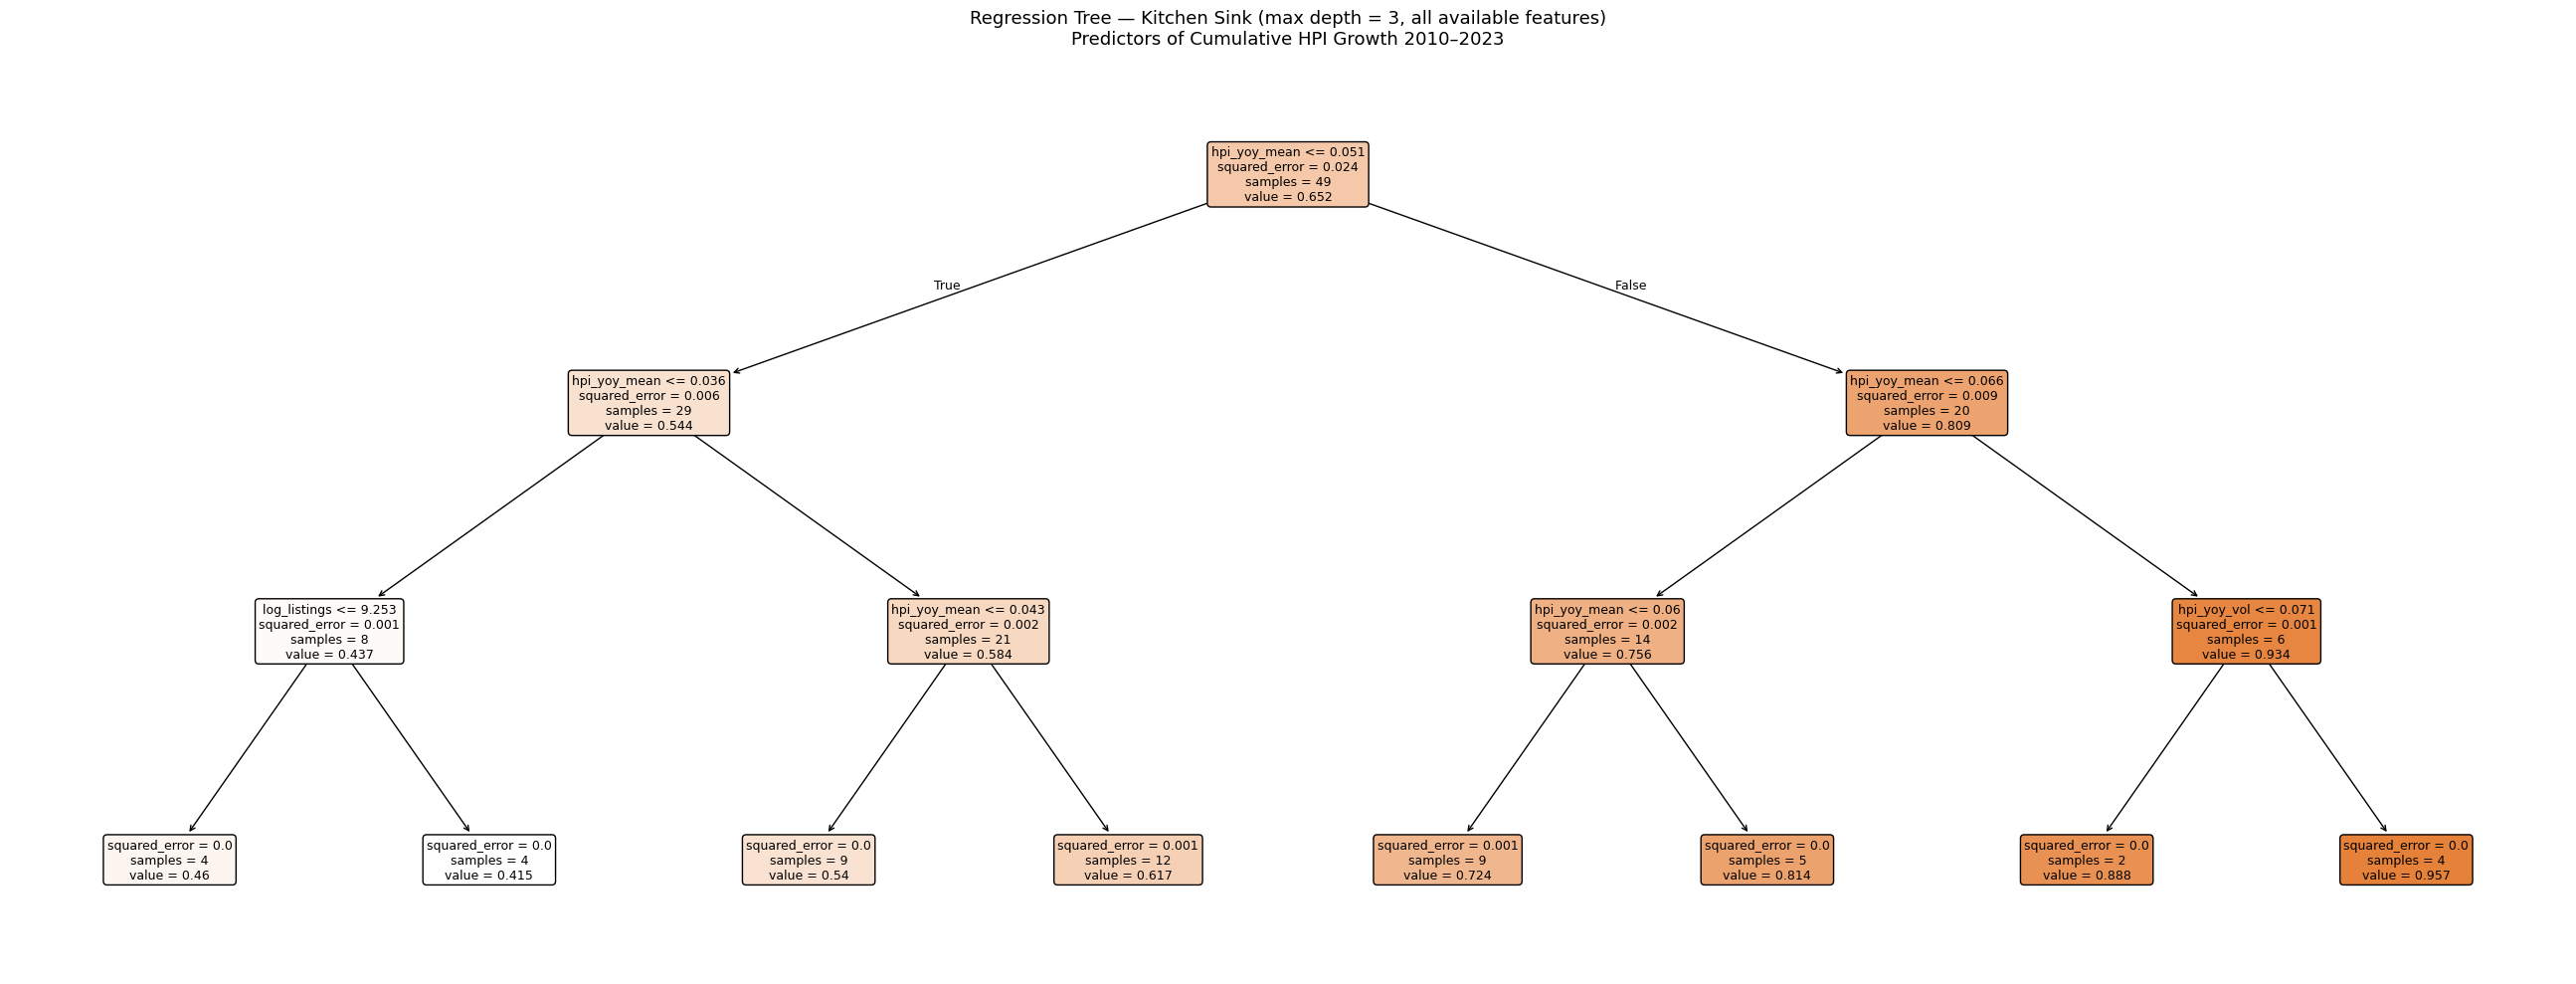

In [ ]:
import pandas as pd
import numpy as np
from sklearn import tree, metrics
import matplotlib.pyplot as plt

df = pd.read_csv("/Users/ziadsaad/Desktop/225 new project/eco225-project-zeyadsaad1/notebooks/output/final_state_with_migration_clean.csv")

df["log_pop"]      = np.log(df["pop_mean"])
df["log_listings"] = np.log(df["listings"])
df["log_income"]   = np.log(df["median_income_mean"])

# All available X variables
ALL_FEATURES = [
    # Labor market
    "unemp_volatility", "unemp_mean", "unemp_min", "unemp_max",
    # HPI dynamics
    "hpi_yoy_mean", "hpi_yoy_vol",
    # Income & population
    "log_income", "log_pop",
    # Housing market structure
    "avg_price", "med_price", "avg_ppsf", "med_ppsf",
    "avg_house_size", "med_house_size",
    "share_ready_to_build", "log_listings",
    # UHaul migration
    "net_migration_mean", "net_migration_vol",
]

ks_df = df[ALL_FEATURES + ["hpi_growth_2010_2023"]].dropna().copy()
X_ks = ks_df[ALL_FEATURES]
y_ks = ks_df["hpi_growth_2010_2023"]

ks_tree = tree.DecisionTreeRegressor(max_depth=3, random_state=42).fit(X_ks, y_ks)

y_pred_ks = ks_tree.predict(X_ks)
print("Kitchen Sink Tree")
print("In-sample MSE : {:.5f}".format(metrics.mean_squared_error(y_ks, y_pred_ks)))
print("In-sample R\u00b2  : {:.3f}".format(metrics.r2_score(y_ks, y_pred_ks)))
print("\nFeature importances:")
ks_importances = pd.Series(ks_tree.feature_importances_, index=ALL_FEATURES).sort_values(ascending=False)
print(ks_importances[ks_importances > 0].to_string())

# Plot
fig, ax = plt.subplots(figsize=(26, 10))
tree.plot_tree(
    ks_tree,
    feature_names=ALL_FEATURES,
    filled=True,
    rounded=True,
    fontsize=9,
    ax=ax
)
ax.set_title(
    "Regression Tree — Kitchen Sink (max depth = 3, all available features)\n"
    "Predictors of Cumulative HPI Growth 2010\u20132023",
    fontsize=13, pad=12
)
plt.tight_layout()
plt.show()

The kitchen sink tree gets an R² of 0.983 by splitting almost entirely on hpi_yoy_mean, the average annual HPI growth rate. But this is related to the outcome, as the cumulative long-run housing growth is the sum of annual growth rates, making the tree not very useful and does not add any economic insight. The preferred specification tree is more informative, it uses independent predictors such as existing price levels, migration flows, income, and unemployment volatility, and explains 65% of the cross-state variation.

The preferred tree has an MSE of 0.009, which means the predictions are off by about ±9 percentage points of housing appreciation, this is reasonable given the outcome ranges from 40% to 95% across states. The kitchen sink tree produces a much lower MSE, but it is misleading because it essentially uses the outcome variable to predict itself. Therefore, the preferred tree's error is the more reliable estimate.

## Random Forest

Random Forest (n=500 trees, max_depth=3)
In-sample MSE : 0.00521
In-sample R²  : 0.784


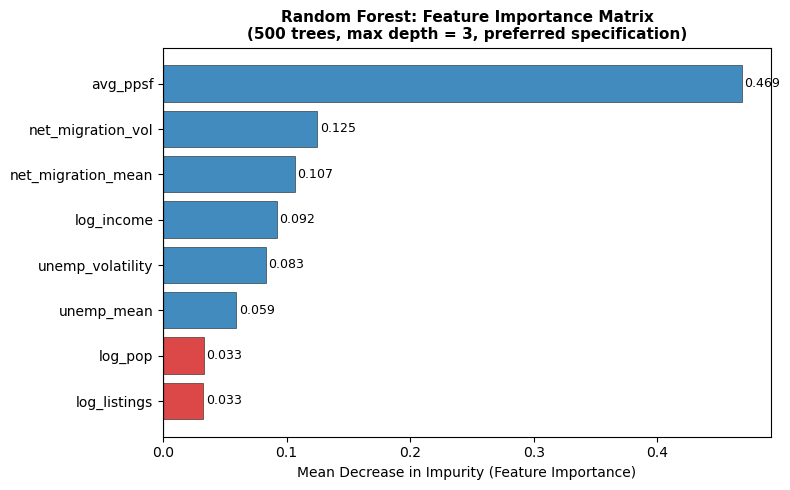

In [80]:
import pandas as pd
import numpy as np
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, r2_score
import matplotlib.pyplot as plt

df = pd.read_csv("/Users/ziadsaad/Desktop/225 new project/eco225-project-zeyadsaad1/notebooks/output/final_state_with_migration_clean.csv")

df["log_pop"]      = np.log(df["pop_mean"])
df["log_listings"] = np.log(df["listings"])
df["log_income"]   = np.log(df["median_income_mean"])

FEATURES = [
    "unemp_volatility", "unemp_mean",
    "log_income", "log_pop", "log_listings", "avg_ppsf",
    "net_migration_mean", "net_migration_vol",
]

rf_df = df[FEATURES + ["hpi_growth_2010_2023"]].dropna().copy()
X = rf_df[FEATURES]
y = rf_df["hpi_growth_2010_2023"]

# Random forest: 500 shallow trees, same max_depth as the single tree for comparability
rf = RandomForestRegressor(n_estimators=500, max_depth=3, random_state=42)
rf.fit(X, y)

y_pred = rf.predict(X)
print("Random Forest (n=500 trees, max_depth=3)")
print("In-sample MSE : {:.5f}".format(mean_squared_error(y, y_pred)))
print("In-sample R\u00b2  : {:.3f}".format(r2_score(y, y_pred)))

# Feature importance plot
importances = pd.Series(rf.feature_importances_, index=FEATURES).sort_values()

fig, ax = plt.subplots(figsize=(8, 5))
colors = ["#d62728" if v < 0.05 else "#1f77b4" for v in importances.values]
ax.barh(importances.index, importances.values, color=colors, alpha=0.85,
        edgecolor="black", linewidth=0.4)
ax.axvline(0, color="black", linewidth=0.8)
ax.set_xlabel("Mean Decrease in Impurity (Feature Importance)", fontsize=10)
ax.set_title("Random Forest: Feature Importance Matrix\n(500 trees, max depth = 3, preferred specification)", 
             fontsize=11, fontweight="bold")
for i, (val, name) in enumerate(zip(importances.values, importances.index)):
    ax.text(val + 0.002, i, "{:.3f}".format(val), va="center", fontsize=9)
plt.tight_layout()
plt.show()

Price per square foot dominates at 47%, confirming that expensive and supply-constrained markets continued appreciating the most, which aligns with what the regressions have shown. Migration variables rank second and third combined at around 23%, which suggests that population flows are a stronger predictor of housing returns than labor market conditions alone. Unemployment volatility registers at 8%, which is meaningful and supports the regression finding that labor market risk contributes to housing appreciation. The main new insight is the hierarchy the forest reveals: housing market structure first, migration second, economic risk third, since the regressions confirmed volatility matters but could not rank it against other predictors this cleanly.

## OLS vs ML
The OLS results in Table 4 show that unemployment volatility has a positive and statistically significant effect on housing returns (0.153 to 0.167 across specifications), but the model assumes this relationship holds equally across all 49 states. Every variable gets one coefficient and the model adds them up linearly, which is clean but leans toward a one-size-fits-all interpretation.

The regression tree tells a different story; price per square foot accounts for 58% of feature importance, migration volatility and mean together account for another 30%, and unemployment volatility only contributes about 4%. The tree is showing that volatility only becomes relevant after housing market structure and migration patterns have already explained most of the variation. OLS does not show this because it estimates all variables simultaneously and independently.

Economically, this means the risk premium story from the regression is real but conditional. In expensive, high-migration states, structural forces dominate housing returns regardless of labor market risk. The premium tied to volatility is more likely showing up in affordable states where instability has not already been priced into the market, something the tree can show but OLS cannot.

## Conclusion

This paper examined whether U.S. states with more volatile labor markets tend to experience higher long-run housing price appreciation, using the standard deviation of unemployment rates as a proxy for local economic risk. Across 49 states from 2010 to 2023, both housing returns and unemployment volatility varied substantially, providing the cross-sectional variation needed to test the risk premium hypothesis.

The regression results support the core argument. Unemployment volatility is positively and significantly associated with cumulative housing price growth across all specifications, including after controlling for income, population, housing market structure, and domestic migration flows from U-Haul transaction data. The interaction with high-income states shows the effect weakens where labor market conditions are more stable, while the migration controls confirm the effect is not simply demand. The machine learning results show that price-per-square foot dominates as the strongest predictor, followed by migration flows, with unemployment volatility ranking even lower. This suggests the risk premium is conditional rather than universal, appearing most clearly in affordable states where economic instability is not already embedded in housing prices.

Several limitations must be noted, such as the Kaggle housing data being a 2022 snapshot, making price-per-square-foot time-invariant. Replacing it with annual Zillow data would allow for time-varying controls. The U-Haul migration data covers only 2015-2023, and relies on truck rentals rather than census records, which creates measurement error in low-volume states. Additionally, the cross-sectional design of the research prevents controlling for unobserved state fixed effects.

## References

Anundsen, A. K., & Heebøll, C. (2015). Supply restrictions, subprime lending and regional US house prices. SSRN Electronic Journal. https://doi.org/10.2139/ssrn.2580785

Case, K., & Shiller, R. (1988). The efficiency of the market for single-family homes. https://doi.org/10.3386/w2506

Glaeser, E. L., Gyourko, J., & Saiz, A. (2008). Housing supply and housing bubbles. Journal of Urban Economics, 64(2), 198–217. https://doi.org/10.1016/j.jue.2008.07.007

Mian, A., & Sufi, A. (2009). The consequences of mortgage credit expansion: Evidence from the U.S. mortgage default crisis. Quarterly Journal of Economics, 124(4), 1449–1496. https://doi.org/10.1162/qjec.2009.124.4.1449

Naranjo, A., & Ling, D. C. (1997). Economic risk factors and commercial real estate returns. The Journal of Real Estate Finance and Economics, 14(3), 283–307. https://doi.org/10.1023/a:1007754312084

Piazzesi, M., Schneider, M., & Tuzel, S. (2007). Housing, consumption and asset pricing. Journal of Financial Economics, 83(3), 531–569. https://doi.org/10.1016/j.jfineco.2006.01.006

Sagi, J. S. (2020). Asset-level risk and return in real estate investments. The Review of Financial Studies, 34(8), 3647–3694. https://doi.org/10.1093/rfs/hhaa122

Saiz, A. (2010). The geographic determinants of housing supply. Quarterly Journal of Economics, 125(3), 1253–1296. https://doi.org/10.1162/qjec.2010.125.3.1253

Shilling, J. D. (2003). Is there a risk premium puzzle in real estate? Real Estate Economics, 31(4), 501–525. https://doi.org/10.1046/j.1080-8620.2003.00075.x

Van Nieuwerburgh, S., & Weill, P.-O. (2010). Why has house price dispersion gone up? Review of Economic Studies, 77(4), 1567–1606. https://doi.org/10.1111/j.1467-937x.2010.00611.x

Zhu, B., & Lizieri, C. (2022). Local beta: Has local real estate market risk been priced in REIT returns? The Journal of Real Estate Finance and Economics, 69(4), 682–718. https://doi.org/10.1007/s11146-022-09890-4